# Version 2 — construire une stratégie qui n'achète que des **ETF**

**Pourquoi ce notebook.** La méthode M3 fonctionne sur les titres. Mais le portefeuille qu'on veut livrer
n'achète pas de titres : il n'achète que des **ETF**. La spécification est écrite depuis le début —
*pour chaque ticker déclaré, on substitue l'ETF correspondant ; la logique d'entrée et de sortie reste
strictement identique, **seul l'instrument change**.*

**Où l'on en est, et pourquoi ce n'est pas suffisant.** La version fidèle à cette spécification existe
(notebook 13, §12) : on calcule M3 en entier, puis on remplace chaque ligne par son ETF sectoriel et l'on
somme les poids. Elle rend **+1,92 et +1,12 %/an** sur 2019-2026 — positif des deux côtés, mais **la moitié
de l'excès de M3 a disparu**, et son $t$ plafonne à 1,0.

**Le diagnostic est fait, et il dicte ce notebook.** Trois faits mesurés au §12 du notebook 13 :

| ce qui a été mesuré | ce que ça implique |
|---|---|
| le consensus **sature** : $m$ varie d'un facteur $\approx 2{,}4$ entre secteurs, contre 17 à 22 entre titres | $s = B\times m$ dégénère en $s \propto B$ : au niveau du secteur, M3 **est** M2 |
| le score sectoriel classe les secteurs **comme le marché les pèse** ($\rho$ de rang 0,85 et 0,88) | on achèterait les gros secteurs parce qu'ils sont gros |
| il n'y a que **onze lignes** | le top-150 ne coupe rien, et $11\times 10\,\% = 110\,\%$ : le plafond rend l'équipondéré |

**Les trois ont une racine commune : onze lignes, c'est trop peu.** Ce notebook attaque donc d'abord
l'**univers**, puis le **score**, puis la **forme** du portefeuille — dans cet ordre, parce que c'est
l'ordre de leur importance mesurée.

### Le plan, et la discipline
1. **§2 — le test qui décide** : y a-t-il seulement de l'information au niveau sectoriel ? Si non, aucun
   raffinement de pondération ne sauvera quoi que ce soit, et il faut le savoir *avant* de construire.
2. **§3 — l'univers** : passer de 11 à une trentaine d'ETF. La carte est **déclarée avant** tout backtest.
3. **§4 — le score** : le débarrasser de l'effet taille.
4. **§5 — la forme** : *le marché, plus un tilt* — la seule dont un allocataire pilote le risque.
5. **§6 — l'exécution** : coûts, rotation, perte maximale, capacité.

⚠️ **Règles tenues d'un bout à l'autre** : tous les runs sont **déclarés avant d'être lancés** et **tous
sont publiés**, y compris les nuls ; aucun paramètre n'est retenu sur le rendement ; et **aucun seuil de
bruit** n'est affiché — à sa place, la **puissance**, c'est-à-dire l'excès qu'il faudrait pour conclure.

### Ce que ce notebook ne fera pas
Il ne modifiera ni `sector_enrich.py` ni le mapping GICS du dépôt *(le toucher invaliderait le cache de
4 848 tickers)*, et il n'écrira rien dans `cache/prices_v2/` *(des notebooks archivés assertent son
contenu)*. Toute donnée nouvelle va dans un répertoire **frère**.

---
# Partie I — le socle

Ce qui suit est **le notebook 13, à l'identique** : mêmes données, même moteur, même spécification M3,
mêmes mesures. Les cellules sont extraites de son builder plutôt que recopiées, pour qu'aucune divergence
ne soit possible. On s'arrête au résultat de M3 : c'est la référence contre laquelle tout sera comparé.

# La méthode M3 — pondérer au dollar **et** au nombre d'élus

Chaque fin de mois, pour un parti : on regarde les achats que ses élus ont **divulgués** sur les trois
dernières années, on note chaque titre par **le montant acheté multiplié par le nombre d'élus acheteurs**,
on garde les 150 premiers, on plafonne chaque ligne à 10 %, et on tient le panier un mois.

**Ce notebook est autonome.** Il ne dépend d'aucun autre : il repart du fichier de transactions propre et du
cache de prix, recopie le moteur, et se re-prouve à chaque étape. Il ne contient qu'une méthode — M3 — et
les décompositions qui expliquent son résultat.

### La spécification, en six points

À chaque fin de mois $t$, pour le parti $P$ :

1. **fenêtre** — les opérations **divulguées** sur $(t - 756\ \text{j};\ t]$, soit environ trois ans de bourse ;
2. **sens** — les **achats** seulement (une vente de vieille ligne n'est pas un signal négatif) ;
3. **score** — $\;s_i = B_i \times m_i\;$ où $B_i = \sum_k A_k$ est le montant acheté du titre $i$
   ($A_k$ = milieu de la fourchette déclarée) et $m_i$ le nombre d'**élus distincts** qui l'ont acheté ;
4. **univers** — les **150** plus gros $s_i$, parmi les titres qui cotent (§2) ;
5. **poids** — $\;w_i = \min(c,\ \lambda v_i)\;$ avec $v_i = s_i / \sum_j s_j$ et $\lambda$ l'unique réel tel
   que $\sum_i w_i = 1$ ; plafond $c = 8{,}5\,\%$ ;
6. **exécution** — au **close du lendemain** de la coupe, puis on ne touche plus à rien jusqu'au mois suivant.

**La conséquence du produit.** Si $K$ élus achètent le même titre pour le même montant $a$, alors
$B_i = Ka$, $m_i = K$, donc $s_i = K^2 a$ : le consensus compte **au carré**. C'est le seul endroit de toute
la méthode où l'on s'écarte d'une pondération au dollar.

### Les constantes, et ce qui les fixe

| constante | valeur | ce qui la fixe — jamais notre rendement |
|---|---|---|
| $W_3$ | 756 j (3 ans) | la règle publiée du fonds |
| $A_k$ | milieu de fourchette | la règle publiée du fonds |
| $\delta$ (divulgation) | — | la date de transaction n'est pas investissable |
| $N$ | 150 | le prospectus annonce 100 à 200 lignes |
| $c$ | 10 % | la médiane du fonds réel sur 13 dates **et** la limite UCITS |
| rythme | mensuel | l'hebdomadaire ne change rien (22,3 contre 22,6 %) |
| $\theta$ | 50 opérations | la description d'un gérant, pas un réglage *(M4 seulement)* |

### Ce que ce notebook n'établit pas

L'excès de M3 **n'est pas significatif** — son intervalle de confiance contient zéro. On livre la méthode la
mieux fondée, pas une méthode dont on prouve qu'elle gagne. · Les résultats sont **bruts de frais** partout
sauf au §8, qui les facture. · La fidélité au vrai fonds NANC/GOP et l'audit de la formule vivent dans le
notebook 11, ils ne sont pas repris ici.

### Une règle de démarrage, et pourquoi elle existe

Le plafond de 10 % n'a de solution que si l'univers compte au moins dix titres. À la toute première fin
de mois, en janvier 2014, la fenêtre de trois ans ne contient qu'un mois de déclarations et les démocrates
n'ont que **neuf** titres éligibles : le plafond y est inapplicable et le portefeuille serait équipondéré,
donc pas celui que la spécification décrit. **Le backtest ne démarre qu'à la première coupe où la règle est
applicable aux deux partis** — le 28 février 2014. Le critère est structurel, il ne fait intervenir aucun
rendement, et il fait légèrement *baisser* le résultat.

### Les chiffres que ce notebook doit retrouver

Ce sont ceux du notebook 11, mesurés sur **les 150 coupes**. **Si l'extraction ne les reproduit pas, elle
est fausse** — c'est le §6.1 (a) qui tranche. Les chiffres *publiés* par ce notebook, eux, sont ceux des
coupes conformes ; le §6.1 (b) affiche les deux côte à côte.

| | NANC (Démocrates) | GOP (Républicains) |
|---|---|---|
| NAV finale (base 100) | **672,35** | **612,25** |
| excès %/an · $t$ | +2,98 · 1,47 | +1,24 · 1,62 |
| IC 95 % de l'excès | [−1,44 ; +7,40] | [−0,42 ; +2,90] |
| $\alpha_1$ · $\alpha_4$ (%/an) | +1,26 · +1,75 | +1,12 · +1,68 |
| $\beta$ marché | 1,077 | 1,004 |
| années gagnantes | 9/13 | 10/13 |

In [1]:
import os, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
FF_CSV = f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv"
FIGS   = f"{RACINE}/00. S3S4 en cours/figs_nb13"
os.makedirs(FIGS, exist_ok=True)

W3, TOPN, CAP = 756, 150, 0.10           # les trois constantes de M3
print(f"W₃ = {W3} j (≈ 3 ans) · N = {TOPN} titres · c = {100*CAP:.1f} %")
print(f"figures → {FIGS}")

W₃ = 756 j (≈ 3 ans) · N = 150 titres · c = 10.0 %
figures → /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/figs_nb13


### §1.1 — Choisir le sous-ensemble

**La table est déjà propre** : c'est le produit du pipeline S1/S2 (dédoublonnage, dates réparées, tickers
résolus, montants parsés). On ne nettoie rien, on choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; \delta_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, date de
divulgation, sens, milieu de fourchette.

La colonne `etf_proxy` est chargée bien qu'inutile à M3 : elle porte l'ETF sectoriel de chaque titre, et
c'est par elle que passera la variante ETF (§9). Une colonne de plus ne change aucun filtre — le §1.5 le
vérifie.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics",
                                  "flag_late_filing","party","etf_proxy"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                                 # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]  # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,etf_proxy,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,XLE,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,XLE,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,XLRE,buy,8000.5,2014-01-02,2014-01-27,False


In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### §1.3 — Charger les prix, et re-prouver leur santé

Les garde-fous sont ceux des notebooks amont, ré-appliqués ici **parce que ce notebook est autonome** — ce
n'est pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.5) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes (§2).

**Les onze ETF sectoriels SPDR sont chargés en plus des titres.** Ils ne peuvent pas entrer dans M3 : le
périmètre du §1.1 ne garde que `asset_class == "stock"`, et ces onze-là sont classés `etf_sector`. Ils sont
là pour le §9. Le §1.5 vérifie que leur présence ne fait entrer aucune ligne dans le flux.

In [4]:
ETF_SECT = ["XLB","XLC","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]   # les 11 secteurs GICS

PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(set(df.tk.unique()) | set(ETF_SECT)):        # ← l'union : les titres ET les 11 ETF
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()

PXV_ACTIONS = set(df.tk.unique()) & set(PXV)                  # ← le périmètre de M3, hors ETF
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV_ACTIONS):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")
print(f"ETF sectoriels chargés en plus : {len(set(PXV) - PXV_ACTIONS)}/11  (pour le §9, hors périmètre M3)")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)
ETF sectoriels chargés en plus : 11/11  (pour le §9, hors périmètre M3)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # exécution à la transaction τ
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution à la divulgation δ — celle de M3
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### §1.4 — Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers d'actions en est un **sous-ensemble** : actions
seules, 2014-2026. L'inclusion doit donc être stricte. Le test porte sur `PXV_ACTIONS`, pas sur `PXV` —
sinon on parierait sur la présence des ETF dans une table qu'on ne contrôle pas.

In [6]:
t09 = pd.read_csv(f"{RACINE}/00. S3S4 en cours/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = PXV_ACTIONS - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"13 · titres chargés (actions 2014-2026)  : {len(PXV_ACTIONS):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
13 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09


### §1.5 — Validation : les deux préparatifs du §9 ne touchent à rien

Deux choses ont été écrites ici pour la variante ETF : la colonne `etf_proxy` chargée, et les onze SPDR
ajoutés au cache de prix. Ni l'une ni l'autre ne doit modifier le flux de M3. On le vérifie plutôt que de
l'affirmer.

In [7]:
# (1) aucun des 11 ETF sectoriels n'apparaît dans le flux : ils sont classés `etf_sector`, jamais `stock`
inter = set(df.tk.unique()) & set(ETF_SECT)
assert not inter, f"un ETF sectoriel est entré dans le flux de M3 : {inter}"

# (2) le flux a la taille attendue, celle du notebook 11
assert len(df) == 113_369, f"flux = {len(df):,} lignes, attendu 113 369 (le périmètre a bougé)"

# (3) etf_proxy est utilisable : rempli partout, et à valeurs dans les 11 secteurs
assert df.etf_proxy.notna().all(), f"{df.etf_proxy.isna().sum()} lignes sans etf_proxy"
assert set(df.etf_proxy.unique()) <= set(ETF_SECT), f"etf_proxy hors des 11 SPDR : {set(df.etf_proxy.unique()) - set(ETF_SECT)}"

print(f"✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux ({len(df):,} trades, inchangé)")
print(f"✅ etf_proxy renseigné sur 100 % des {len(df):,} lignes, à valeurs dans les 11 secteurs GICS")

✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux (113,369 trades, inchangé)
✅ etf_proxy renseigné sur 100 % des 113,369 lignes, à valeurs dans les 11 secteurs GICS


## §2 — L'univers investissable $\mathcal{U}_t$ et les coupes

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement nul et risque nul,
qui gonflerait le résultat sans jamais perdre d'argent.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # le titre cote DÉJÀ (sa série a commencé) ET cote ENCORE (dernier cours à moins de 4 jours)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4

mort = sum(1 for tk in PXV_ACTIONS if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV_ACTIONS):,} "
      f"({mort/len(PXV_ACTIONS):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


In [9]:
# les coupes commencent avec la donnée : dernier jour coté de chaque mois, à partir de janvier 2014
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if 21 <= i < len(cal) - 1))
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")
print(f"première coupe : indice {coupes[0]} dans le calendrier (qui démarre en {cal[0].year})")

150 coupes mensuelles · 2014-01-31 → 2026-06-30
première coupe : indice 522 dans le calendrier (qui démarre en 2012)


### §2.1 — Validation : le seuil de la première coupe ne mord pas

Le notebook 11 écrivait cette borne avec la fenêtre de sa première méthode ($W = 21$ j, puis 42 j sans que
la liste soit recalculée). Ici on l'écrit en dur, à 21 — mais il faut prouver que ce choix est sans effet.
Il l'est parce que le calendrier de prix démarre en 2012 alors que les coupes démarrent en 2014 : la
première coupe a un indice bien supérieur à toute fenêtre envisagée.

In [10]:
def _coupes(seuil):
    c = [cal.searchsorted(d, side="right") - 1 for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
    return sorted(set(i for i in c if seuil <= i < len(cal) - 1))

for s in [0, 21, 42, 126]:
    assert _coupes(s) == coupes, f"le seuil {s} change la liste des coupes"
print(f"✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de {len(coupes)} coupes")
print(f"   (la 1ʳᵉ coupe est à l'indice {coupes[0]} ≫ 126 : la borne ne peut pas mordre)")

✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de 150 coupes
   (la 1ʳᵉ coupe est à l'indice 522 ≫ 126 : la borne ne peut pas mordre)


## §3 — Le moteur d'exécution

Le moteur ne connaît pas la méthode : il reçoit un dictionnaire de **poids cibles** par coupe et fabrique
une NAV. Ce qu'il fait, dans l'ordre, à chaque coupe :

- il **achète au close du lendemain** ($e = t+1$) — jamais au cours de la coupe elle-même ;
- il convertit les poids en **nombres de parts**, puis n'y touche plus : entre deux coupes le portefeuille
  **dérive** avec les cours, exactement comme un portefeuille réel ;
- il mesure la **rotation réalisée** $\;\mathrm{TO}_t = \tfrac12 \sum_i |w^{\text{réalisé}}_i - w^{\text{dérivé}}_i|$ ;
- deux réglages **neutres par défaut** : un frein de rotation $\tau_{\max}$ (§8) et un coût $c$ en points de
  base (§8). À $\tau_{\max} = \infty$ et $c = 0$, aucune opération n'est faite — la NAV est bit-identique.

$$\lambda_R = \min\!\Bigl(1, \frac{\tau_{\max}}{\mathrm{TO}_t}\Bigr), \qquad
w^{\text{réalisé}}_i = w^{\text{dérivé}}_i + \lambda_R\,(w^{\text{cible}}_i - w^{\text{dérivé}}_i), \qquad
V_t \leftarrow V_t\,(1 - 2\,\mathrm{TO}_t\,c)$$

Le **facteur 2** sur le coût : $\tfrac12\sum|\Delta w|$ est le montant *acheté*, égal au montant *vendu* ;
on paie des deux côtés.

In [11]:
TAU_MAX = 0.25                                                        # frein de rotation, en %/mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None, cout_bps=0.0):
    # moteur d'UN livre : parts, buy-and-hold, frein de rotation, frais. Rend (NAV, rotations réalisées)
    # tau_max=∞ et cout_bps=0 → aucune opération n'est faite : la NAV est celle du buy-and-hold pur
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du frein, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]).
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        if cout_bps: V[e] *= 1.0 - 2.0*turns[-1]*cout_bps/1e4
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # rotation hors 1er déploiement

### §3.1 — Validation : un mois recalculé à la main, hors moteur

On prend deux titres à poids connus, on fabrique la NAV à la main sur un mois, et on vérifie que le moteur
donne la même chose. C'est le seul moyen de savoir que « close J+1, parts figées, dérive » est bien ce qui
est implémenté, et pas seulement ce qui est écrit.

In [12]:
tk1, tk2 = "AAPL", "MSFT"
j0, j1 = coupes[60], coupes[61]                       # deux coupes consécutives quelconques
WP_test = {j0: {tk1: 0.60, tk2: 0.40}, j1: {tk1: 0.60, tk2: 0.40}}
V_test, _ = run_livre(WP_test, np.inf, cuts=[j0, j1, coupes[62]])

e = j0 + 1                                            # on achète au close du LENDEMAIN de la coupe
q1 = 100.0 * 0.60 / PXV[tk1][e]                       # parts, figées jusqu'à la coupe suivante
q2 = 100.0 * 0.40 / PXV[tk2][e]
for t in [e, e + 5, j1]:                              # trois dates dans le mois
    a_la_main = q1*PXV[tk1][t] + q2*PXV[tk2][t]
    assert abs(V_test.loc[cal[t]] - a_la_main) < 1e-9, f"écart au jour {cal[t].date()}"

print(f"achat au close du {cal[e].date()} (la coupe est le {cal[j0].date()}) — {q1:.4f} × {tk1} + {q2:.4f} × {tk2}")
print(f"NAV à la coupe suivante : moteur {V_test.loc[cal[j1]]:.6f} · à la main {q1*PXV[tk1][j1]+q2*PXV[tk2][j1]:.6f}")
print("✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit")

achat au close du 2019-02-01 (la coupe est le 2019-01-31) — 1.5186 × AAPL + 0.4178 × MSFT
NAV à la coupe suivante : moteur 106.442585 · à la main 106.442585
✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit


## §4 — M3 : la spécification, et son code

$$w^{P}_{i,t} \;=\; \Pi_c\!\left(\frac{s_{i,t}}{\sum_{j \in \mathcal{S}} s_{j,t}}\right), \qquad
s_{i,t} \;=\; \underbrace{\Big(\textstyle\sum_{k\,:\,P,\ \text{achat},\ t-W_3<\delta_k\le t} A_k\Big)}_{B_i\ \text{: les dollars}}
\;\times\; \underbrace{\#\{\text{élus de }P\text{ acheteurs de } i\}}_{m_i\ \text{: le consensus}}$$

où $\mathcal{S}$ est l'ensemble des 150 plus gros scores et $\Pi_c$ le plafonnement à $c = 10\,\%$.

**Le plafonnement est un remplissage par niveau, pas un écrêtage.** $\Pi_c$ cherche l'unique $\lambda$ tel
que $\sum_i \min(c, \lambda v_i) = 1$ : les lignes qui touchent le plafond y restent, les autres montent
proportionnellement. Comme $\lambda \mapsto \sum_i \min(c, \lambda v_i)$ croît continûment de 0 à
$|\mathcal{S}|\,c$, ce $\lambda$ existe et est unique **dès que** $|\mathcal{S}| \ge \lceil 1/c \rceil = 10$
titres. En dessous de 10, aucune solution n'existe — on y revient au §4.1, qui en tire la règle de démarrage.

**Le filtre anti-bruit** ($\theta$) écarte toute opération appartenant à un dépôt de $\theta$ opérations ou
plus du même élu le même jour : un rééquilibrage automatique de courtier n'est pas une décision. M3 ne
l'applique pas ($\theta = \infty$) ; M4 l'applique à $\theta = 50$.

In [13]:
# ── fenêtrage sur la DIVULGATION δ : l'index trié une fois pour toutes ──
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]

FUSION = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}   # classes d'actions = une société

def cap_poids(w, cap=CAP):
    # remplissage par niveau : w_i = min(cap, λ·v_i), λ trouvé par redistribution itérative de l'excédent
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

# taille du dépôt = nb d'opérations déclarées par le même élu le même jour de divulgation.
# Définie ICI, avec poids_methode qui la lit — même à θ=∞ la colonne doit exister.
df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")

def _instrument(g, univers="titres"):
    # LE point de substitution : ce que le portefeuille achète réellement.
    #   "titres" → le titre lui-même, classes d'actions fusionnées (M3)
    #   "etf"    → l'ETF sectoriel SPDR du titre (§9)
    if univers == "titres": return g.tk.map(lambda t: FUSION.get(t, t))
    if univers == "etf":    return g.etf_proxy
    raise ValueError(f"univers inconnu : {univers}")

SEUIL_BRUIT = 50          # θ — DÉCLARÉ AVANT tout calcul de rendement (M4 seulement)

def poids_methode(i1, parti, topN=TOPN, cap=CAP, seuil=np.inf, mode="score", univers="titres"):
    # M3 = les valeurs par défaut. `mode` ne change QUE la pondération : l'univers reste défini par le score.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy") & (g.taille_depot < seuil)]
    if not len(g): return {}
    g       = g.assign(tkm=_instrument(g, univers))
    buy     = g.groupby("tkm").A.sum()                                   # B_i : les dollars
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)  # m_i : les élus
    score   = (buy * breadth).dropna()
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)               # ← l'UNIVERS, toujours par le score
    if not len(score) or score.sum() <= 0: return {}
    w = {"score":   score,
         "dollars": buy.reindex(score.index),
         "elus":    breadth.reindex(score.index).astype(float),
         "equal":   pd.Series(1.0, index=score.index)}[mode]
    if w.sum() <= 0: return {}
    return cap_poids(w / w.sum(), cap).to_dict()

def cibles_methode(parti, **kw):
    return {i: poids_methode(i, parti, **kw) for i in coupes[:-1]}

PARTIS = [("Democrat", "NANC"), ("Republican", "GOP")]
print(f"M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N={TOPN}, c={100*CAP:.0f} %")

M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N=150, c=10 %


### §4.1 — La règle de démarrage : le backtest commence où la spécification est applicable

Le plafond $c = 10\,\%$ n'a de solution que si l'univers compte au moins $\lceil 1/c\rceil = 10$ titres
(§4.3). En dessous, `cap_poids` rend l'équipondéré : le portefeuille ne serait plus celui que la
spécification décrit. **On ne démarre donc le backtest qu'à la première coupe où la règle est applicable aux
deux partis.**

Ce critère est **structurel** : il se calcule sur le nombre de titres éligibles, sans qu'aucun rendement
n'intervienne. Il ne peut donc pas être un réglage déguisé — et de fait, il fait légèrement *baisser* le
résultat.

*Pourquoi le cas se présente : le signal regarde trois ans en arrière, mais les données commencent en 2014.
À la première fin de mois, la fenêtre ne contient qu'un mois de déclarations au lieu de trente-six.*

In [14]:
SEUIL_DEG = math.ceil(1/CAP)                      # en dessous, le plafond n'a pas de solution
card = {i: {nom: len(poids_methode(i, parti)) for parti, nom in PARTIS} for i in coupes[:-1]}
conformes = [i for i in coupes[:-1] if min(card[i].values()) >= SEUIL_DEG]
i_start   = conformes[0]

print(f"titres retenus aux 5 premières fins de mois (seuil = {SEUIL_DEG}) :")
for i in coupes[:5]:
    ok = "✓" if min(card[i].values()) >= SEUIL_DEG else "✗  ← le plafond n'a pas de solution"
    print(f"   {cal[i].date()} : NANC {card[i]['NANC']:3d} · GOP {card[i]['GOP']:3d}   {ok}")

coupes_tout = list(coupes)                         # gardé : sert au contrôle de non-régression du §6.1
coupes = [i for i in coupes if i >= i_start]       # ← le calendrier du backtest publié
print(f"\ndépart : {cal[i_start].date()} (achat au close du {cal[i_start+1].date()}) · "
      f"{len(coupes)} coupes retenues sur {len(coupes_tout)}")

titres retenus aux 5 premières fins de mois (seuil = 10) :
   2014-01-31 : NANC   9 · GOP  24   ✗  ← le plafond n'a pas de solution
   2014-02-28 : NANC  99 · GOP 112   ✓
   2014-03-31 : NANC 115 · GOP 150   ✓
   2014-04-30 : NANC 136 · GOP 150   ✓
   2014-05-30 : NANC 150 · GOP 150   ✓

départ : 2014-02-28 (achat au close du 2014-03-03) · 149 coupes retenues sur 150


### §4.2 — Le cache : un seul jeu de cibles par variante, et toutes les tables y puisent

Calculer les poids cibles est le seul calcul coûteux du notebook (149 coupes × un regroupement sur ~30 000
lignes). On les calcule **une fois**, dans `WPM`, et **`SER` en dérive**. Ce n'est pas une optimisation :
c'est ce qui rend impossible qu'un tableau du §5 affiche 672,35 et qu'un tableau du §8 affiche 672,31.

In [15]:
import time
t0 = time.time()

KWM = {"M3 · $ × élus":     dict(),                                    # ← LA méthode
       "M2 · dollars purs": dict(mode="dollars"),                      # la pondération sans le consensus
       "élus seuls":        dict(mode="elus"),                         # le consensus sans les dollars
       "équipondéré":       dict(mode="equal"),                        # ni l'un ni l'autre
       "M4 · + filtre θ=50": dict(seuil=SEUIL_BRUIT)}                  # M3 + le filtre anti-bruit
for th in [10, 20, 100]:
    KWM[f"θ = {th}"] = dict(seuil=th)

WPM = {}                                                               # (variante, fonds) → {coupe: {tk: w}}
for parti, nom in PARTIS:
    for m, kw in KWM.items():
        WPM[(m, nom)] = cibles_methode(parti, **kw)
SER = {k: run_livre(WP, np.inf)[0] for k, WP in WPM.items()}           # les NAV en dérivent

n_poids = sum(len(w) for WP in WPM.values() for w in WP.values())
print(f"{len(WPM)} jeux de cibles · {n_poids:,} poids · calculés en {time.time()-t0:.1f} s")

16 jeux de cibles · 352,002 poids · calculés en 15.0 s


In [16]:
# VALIDATION §4.2 — le cache est complet et cohérent, et tout le notebook lira CES objets
assert len(WPM) == 2*len(KWM), f"cache incomplet : {len(WPM)} jeux au lieu de {2*len(KWM)}"
for (m, f), WP in WPM.items():
    assert set(WP) == set(coupes[:-1]), f"{m}/{f} : jeu de coupes incohérent"
    for i, w in WP.items():
        if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{f} coupe {i} : Σw = {sum(w.values())}"
print(f"✅ {len(WPM)} jeux complets · Σw = 1 à chacune des {len(coupes)-1} coupes de chacun")

✅ 16 jeux complets · Σw = 1 à chacune des 148 coupes de chacun


### §4.3 — Validation : le plafond est bien un remplissage par niveau, et la règle de démarrage suffit

Deux contrôles indépendants du code de `cap_poids` :

1. **le point fixe** — on retrouve $\lambda$ par bissection sur $\sum_i \min(c, \lambda v_i) = 1$ et on
   vérifie que le vecteur obtenu est celui de `cap_poids` ;
2. **plus aucune coupe dégénérée** — quand $|\mathcal{S}| < \lceil 1/c \rceil = 12$, **aucun** $\lambda$ ne
   convient : plafonner tout le monde ne remplit pas le portefeuille, `cap_poids` aplatit et sa
   normalisation finale rend l'**équipondéré**. La règle du §4.1 écarte exactement ces coupes ; on vérifie
   qu'il n'en reste aucune, et on mesure ce que la coupe écartée aurait coûté.

In [17]:
# (1) le point fixe : λ retrouvé par bissection, indépendamment de cap_poids
def lam_bissection(v, cap=CAP):
    lo, hi = 1.0, 1e9
    for _ in range(300):
        lam = 0.5*(lo + hi)
        if sum(min(cap, lam*x) for x in v) < 1.0: lo = lam
        else: hi = lam
    return 0.5*(lo + hi)

ecart_max = 0.0
for i in coupes[10:150:17]:
    lo, hi = np.searchsorted(I_de, i - W3, "right"), np.searchsorted(I_de, i, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == "Democrat") & (g.op == "buy")]
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    sc = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    sc = sc[[t for t in sc.index if t in PXV and np.isfinite(PXV[t][i+1]) and vivant(t, i)]]
    sc = sc.sort_values(ascending=False).head(TOPN)
    if len(sc) < math.ceil(1/CAP): continue
    v   = (sc / sc.sum()).values
    lam = lam_bissection(v)
    ecart_max = max(ecart_max, float(np.abs(np.minimum(CAP, lam*v) - cap_poids(sc/sc.sum()).values).max()))
print(f"✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max {ecart_max:.2e}")
print(f"     ⌈1/c⌉ = {math.ceil(1/CAP)} titres : en dessous, aucun λ ne convient")

✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max 9.71e-17
     ⌈1/c⌉ = 10 titres : en dessous, aucun λ ne convient


In [18]:
# (2) plus aucune coupe dégénérée dans le calendrier retenu
for nom in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", nom)]
    deg = [i for i in coupes[:-1] if WP[i] and len(WP[i]) < SEUIL_DEG]
    assert not deg, f"{nom} : coupes encore dégénérées → {[str(cal[i].date()) for i in deg]}"
    tailles = [len(WP[i]) for i in coupes[:-1] if WP[i]]
    print(f"✅ (2) {nom} — 0 coupe sous {SEUIL_DEG} titres sur {len(coupes)-1} · "
          f"|𝒮| min {min(tailles)} · médiane {int(np.median(tailles))}")

# ce que la coupe écartée aurait valu : elle était équipondérée de fait, pas pondérée par le score
i_ecarte = coupes_tout[0]
for nom, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    w = poids_methode(i_ecarte, parti)
    ecart = np.abs(np.array(list(w.values())) - 1/len(w)).max()
    print(f"\ncoupe écartée du {cal[i_ecarte].date()} — {nom} : |𝒮| = {len(w)} · "
          f"max w {100*max(w.values()):.2f} % · écart à l'équipondéré {ecart:.1e}"
          f"{'  → équipondéré de fait' if ecart < 1e-9 else ''}")

✅ (2) NANC — 0 coupe sous 10 titres sur 148 · |𝒮| min 99 · médiane 150
✅ (2) GOP — 0 coupe sous 10 titres sur 148 · |𝒮| min 112 · médiane 150

coupe écartée du 2014-01-31 — NANC : |𝒮| = 9 · max w 11.11 % · écart à l'équipondéré 1.4e-17  → équipondéré de fait

coupe écartée du 2014-01-31 — GOP : |𝒮| = 24 · max w 10.00 % · écart à l'équipondéré 5.8e-02


### §4.4 — Validation : la conséquence en $K^2$, sur un cas fabriqué

Le produit $B_i \times m_i$ n'est pas une pondération au dollar déguisée. On le vérifie sur trois titres
fabriqués : à montant total identique, celui qu'un plus grand nombre d'élus a acheté doit dominer, et le
rapport des scores doit être exactement le rapport des carrés du nombre d'élus.

In [19]:
cas = pd.DataFrame({"titre": ["A", "B", "C"], "élus": [1, 2, 4], "$ par élu": [40_000, 20_000, 10_000]})
cas["B_i (total $)"] = cas["élus"] * cas["$ par élu"]                  # 40 000 pour les trois
cas["m_i"] = cas["élus"]
cas["s_i = B·m"] = cas["B_i (total $)"] * cas.m_i
cas["poids %"] = 100 * cas["s_i = B·m"] / cas["s_i = B·m"].sum()
display(cas.set_index("titre"))

assert cas["B_i (total $)"].nunique() == 1, "le cas doit être à montant total identique"
assert abs(cas["s_i = B·m"].iloc[2] / cas["s_i = B·m"].iloc[0] - 4) < 1e-12, "le rapport devrait être m_C/m_A = 4"
print(f"✅ à dollars égaux, 4 élus pèsent {cas['s_i = B·m'].iloc[2]/cas['s_i = B·m'].iloc[0]:.0f}× un seul élu")
print("   (le score est K²a pour K élus au montant a : le consensus compte au carré)")

,élus,$ par élu,B_i (total $),m_i,s_i = B·m,poids %
titre,,,,,,
A,1,40000,40000,1,40000,14.285714
B,2,20000,40000,2,80000,28.571429
C,4,10000,40000,4,160000,57.142857


✅ à dollars égaux, 4 élus pèsent 4× un seul élu
   (le score est K²a pour K élus au montant a : le consensus compte au carré)


### §4.4 — D'où vient le plafond de 10 %, et pourquoi pas 8,5 %

Le plafond est le seul paramètre de M3 qui ne se lise pas dans le prospectus : il faut l'**estimer**. Deux
sources indépendantes, dont aucune n'est notre rendement, permettent de le faire — et elles convergent.

1. **Le fonds lui-même**, à travers les treize états de portefeuille qu'il dépose à la SEC.
2. **La réglementation** : 10 % par émetteur est la limite UCITS ; au-delà, un fonds européen n'est plus
   distribuable.

On mesure ici la première, et on regarde ce que le plafond retient réellement — c'est-à-dire à quoi
ressemblerait le portefeuille si on ne plafonnait pas.

In [20]:
NP = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/nport_holdings.csv")
mx = NP.groupby(["fonds", "date"]).pct.max().unstack(0).round(2)
print(f"plus grosse ligne du portefeuille RÉEL, aux {len(mx)} dates N-PORT (%) :")
display(mx)
for f in mx.columns:
    print(f"   {f:5s} médiane {mx[f].median():.2f} % · min {mx[f].min():.2f} % · max {mx[f].max():.2f} %")
print(f"\n→ le plafond retenu, {100*CAP:.0f} %, est la médiane de NANC ({mx['NANC'].median():.1f} %) "
      f"et la limite UCITS.")
print(f"   l'ancien 8,5 % venait d'UNE photo (24/07/2026) — il tombait SOUS le minimum jamais "
      f"observé ({mx['NANC'].min():.2f} %).")
print(f"   ⚠️ côté GOP la contrainte réelle est bien plus serrée ({mx['GOP'].median():.1f} %) : notre "
      f"réplique y est plus concentrée que l'original.")

plus grosse ligne du portefeuille RÉEL, aux 13 dates N-PORT (%) :


fonds,GOP,NANC
date,,
2023-03-31,3.65,7.99
2023-06-30,2.00,9.17
2023-09-30,2.66,10.42
2023-12-31,2.42,9.15
2024-03-31,2.42,10.30
2024-06-30,3.22,12.67
2024-09-30,3.79,11.60
2024-12-31,4.31,11.41
2025-03-31,4.49,8.99


   GOP   médiane 3.79 % · min 2.00 % · max 7.41 %
   NANC  médiane 10.33 % · min 7.99 % · max 12.67 %

→ le plafond retenu, 10 %, est la médiane de NANC (10.3 %) et la limite UCITS.
   l'ancien 8,5 % venait d'UNE photo (24/07/2026) — il tombait SOUS le minimum jamais observé (7.99 %).
   ⚠️ côté GOP la contrainte réelle est bien plus serrée (3.8 %) : notre réplique y est plus concentrée que l'original.


In [21]:
# ce que le plafond retient : la concentration du portefeuille NON contraint, sur toutes les coupes
for parti, nom in PARTIS:
    L = []
    for i in coupes[:-1]:
        w = poids_methode(i, parti, cap=1.0)
        if w:
            t = pd.Series(w).sort_values(ascending=False)
            L.append((100*t.iloc[0], t.index[0], cal[i].date()))
    m = np.array([x[0] for x in L])
    top = sorted(L, reverse=True)[0]
    print(f"{nom} sans plafond — plus grosse ligne : médiane {np.median(m):.1f} % · p90 "
          f"{np.percentile(m,90):.1f} % · MAX {m.max():.1f} % ({top[1]}, {top[2]})")
    print(f"      au-dessus de 20 % : {100*(m>20).mean():.0f} % des coupes · "
          f"au-dessus de 30 % : {100*(m>30).mean():.0f} %")
print(f"\n→ sans plafond ce n'est plus un portefeuille : le plafond arbitre entre rendement et "
      f"concentration,\n   et les deux ancrages ci-dessus disent où placer le curseur.")

NANC sans plafond — plus grosse ligne : médiane 35.7 % · p90 61.3 % · MAX 87.3 % (BRK-B, 2015-03-31)
      au-dessus de 20 % : 82 % des coupes · au-dessus de 30 % : 70 %


GOP sans plafond — plus grosse ligne : médiane 13.3 % · p90 34.8 % · MAX 43.4 % (MMM, 2015-10-30)
      au-dessus de 20 % : 25 % des coupes · au-dessus de 30 % : 24 %

→ sans plafond ce n'est plus un portefeuille : le plafond arbitre entre rendement et concentration,
   et les deux ancrages ci-dessus disent où placer le curseur.


## §5 — La boîte à outils de mesure

Quatre grandeurs, définies une fois, utilisées partout.

**L'excès annuel** — on compose les rendements par année civile, des deux côtés, et on soustrait :
$$x_Y = \prod_{t \in Y}(1+r_t) - \prod_{t \in Y}(1+r^{\mathrm{SPY}}_t), \qquad
t = \frac{\bar x}{\sigma_x/\sqrt{n}}, \qquad \mathrm{IC}_{95} = \bar x \pm t_{0{,}975;\,n-1}\,\frac{\sigma_x}{\sqrt n}$$
Avec $n = 13$ années, il faut $|t| > 2{,}18$ pour conclure. *(Le $t$ de Student, pas 1,96 : $n$ est petit.)*

**Le modèle à un facteur** — $r - r_f = \alpha_1 + \beta\,(r^{\mathrm{SPY}} - r_f) + \varepsilon$, sur données
journalières, $\alpha$ annualisé $\times 252$.

**Le modèle à quatre facteurs** (Fama-French-Carhart) — le même en ajoutant SMB (petites moins grandes),
HML (value moins croissance) et Mom (momentum) :
$$r - r_f = \alpha_4 + \beta_M (r_m - r_f) + \beta_S\,\mathrm{SMB} + \beta_H\,\mathrm{HML} + \beta_U\,\mathrm{Mom} + \varepsilon$$
$\alpha_4$ répond à : *reste-t-il quelque chose une fois retirés le marché, la taille, le style et le momentum ?*

**La concentration** — plus gros poids, somme des 5 premiers, et $N_{\text{eff}} = 1/\sum_i w_i^2$, le nombre
de lignes qu'il faudrait à poids égaux pour être aussi peu concentré.

In [22]:
FF   = pd.read_csv(FF_CSV, parse_dates=["Date"]).set_index("Date")     # une seule lecture pour tout le notebook
FACS = ["Mkt-RF", "SMB", "HML", "Mom"]
print(f"facteurs : {list(FF.columns)} · {FF.index[0].date()} → {FF.index[-1].date()} · {len(FF):,} jours")

ESSAIS = []          # tout run passé au bilan y laisse son nom : c'est le compteur de multiplicité (§11.4)

def bilan(Vx, nom):
    ESSAIS.append(nom)
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(FF[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

def bilan_ic(Vx, nom):
    # bilan() + l'intervalle de confiance de l'excès annuel moyen
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    n, se = len(xx), xx.std(ddof=1)/np.sqrt(len(xx))
    q = float(stats.t.ppf(0.975, n-1))
    b = dict(bilan(Vx, nom))
    b.update({"n ans": n, "IC bas": 100*(xx.mean()-q*se), "IC haut": 100*(xx.mean()+q*se)})
    return b

def facteurs(Vx, nom, cols=FACS):
    # régression OLS multi-facteurs + erreurs-types ; α annualisé ×252
    r = Vx.pct_change().dropna().rename("r")
    d = pd.DataFrame(r).join(FF, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in cols])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o = {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0]}
    for j, c in enumerate(cols, 1):
        o[c] = b[j]; o["t " + c] = b[j]/se[j]
    o["n j"] = len(y)
    return o

def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)

def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1

def conc(w):
    # w : une Series de poids EN POURCENTS, triée décroissante
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1 / float(np.sum(p**2)), 1)

Wab = 252
def roll_ab(span):
    r = span.pct_change().dropna()
    d = pd.DataFrame({"y": r, "m": r_spy.reindex(r.index)}).join(FF[["RF"]]).dropna()
    y, x  = d.y - d.RF, d.m - d.RF
    beta  = y.rolling(Wab).cov(x) / x.rolling(Wab).var()
    alpha = (y.rolling(Wab).mean() - beta * x.rolling(Wab).mean()) * 252 * 100     # α annualisé, %
    return alpha.dropna(), beta.dropna(), y, x

facteurs : ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom'] · 2013-01-02 → 2026-04-30 · 3,352 jours


### §5.1 — Validation : les outils, contrôlés sur le SPY lui-même

Passer l'indice dans nos propres mesures doit rendre l'évidence : $\beta_M \approx 1$, tous les autres
chargements $\approx 0$, $\alpha \approx 0$. Si ce n'était pas le cas, aucun des résultats qui suivent
n'aurait de valeur.

In [23]:
nav_spy_full = (1 + r_spy).cumprod() * 100
v = facteurs(nav_spy_full, "SPY (contrôle)")
assert abs(v["Mkt-RF"] - 1) < 0.05, f"β_MKT du SPY = {v['Mkt-RF']:.3f}, attendu ≈ 1"
assert abs(v["α %/an"]) < 2.0, f"α du SPY = {v['α %/an']:.2f} %/an, attendu ≈ 0"
display(pd.DataFrame([v]).set_index("run").round(3))
print(f"✅ contrôle SPY : β_MKT {v['Mkt-RF']:.3f} ≈ 1 · α {v['α %/an']:+.2f} %/an ≈ 0")

# le fichier de facteurs s'arrête avant la NAV : on dit combien de jours la régression perd
print(f"\nfacteurs disponibles jusqu'au {FF.index[-1].date()} · calendrier de prix jusqu'au {cal[-1].date()}")

,α %/an,t_α,Mkt-RF,t Mkt-RF,SMB,t SMB,HML,t HML,Mom,t Mom,n j
run,,,,,,,,,,,
SPY (contrôle),0.04,0.115,0.98,755.945,-0.123,-54.046,0.012,6.548,-0.009,-6.325,3352


✅ contrôle SPY : β_MKT 0.980 ≈ 1 · α +0.04 %/an ≈ 0

facteurs disponibles jusqu'au 2026-04-30 · calendrier de prix jusqu'au 2026-07-02


## §6 — Ce que M3 vaut

Deux runs, un par parti, même règle. Rien n'a été choisi après avoir vu ces chiffres.

In [24]:
M3 = {nom: SER[("M3 · $ × élus", nom)] for _, nom in PARTIS}
nav_spy_m3 = (1 + r_spy.reindex(M3["NANC"].index).fillna(0)).cumprod() * 100

# le SPY n'est pas mis dans ce tableau : son « excès sur lui-même » vaut zéro, et les colonnes t et
# années gagnantes n'y seraient que du bruit d'arrondi. Il sert de repère de NAV et de rendement, ci-dessous.
PERF = pd.DataFrame([bilan_ic(M3["NANC"], "M3 · NANC (Démocrates)"),
                     bilan_ic(M3["GOP"],  "M3 · GOP (Républicains)")]).set_index("run")
display(PERF[["excès %/an", "t", "n ans", "IC bas", "IC haut", "α %/an", "t_α", "β", "NAV", "ann. gagnantes"]].round(2))

for nom in ["NANC", "GOP"]:
    n = int(np.median([len(WPM[("M3 · $ × élus", nom)][i]) for i in coupes[:-1] if WPM[("M3 · $ × élus", nom)][i]]))
    print(f"{nom} : {n} titres (médiane) · NAV {M3[nom].iloc[-1]:.0f} · total {100*cagr(M3[nom]):.1f} %/an")
print(f"SPY  : repère            · NAV {nav_spy_m3.iloc[-1]:.0f} · total {100*cagr(nav_spy_m3):.1f} %/an")
print(f"\nseuil de significativité à n = {PERF.loc['M3 · NANC (Démocrates)', 'n ans']:.0f} années : "
      f"|t| > {stats.t.ppf(0.975, 12):.2f}  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro")

,excès %/an,t,n ans,IC bas,IC haut,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,,,,
M3 · NANC (Démocrates),3.40,1.61,13,-1.19,7.99,1.66,1.36,1.08,661.57,9/13
M3 · GOP (Républicains),1.24,1.61,13,-0.44,2.91,1.09,1.07,1.00,573.57,9/13


NANC : 150 titres (médiane) · NAV 662 · total 16.6 %/an
GOP : 150 titres (médiane) · NAV 574 · total 15.2 %/an
SPY  : repère            · NAV 494 · total 13.9 %/an

seuil de significativité à n = 13 années : |t| > 2.18  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro


### §6.1 — Validation : l'extraction est-elle fidèle, et que change la règle de démarrage ?

Deux contrôles, à ne pas confondre.

**(a) La fidélité de l'extraction.** Le notebook 11 a publié dix-huit nombres pour M3, sur les 150 coupes.
Ce notebook les recalcule depuis le CSV brut, par un chemin qu'il a lui-même reconstruit. S'ils ne
coïncident pas, l'extraction a changé quelque chose et tout le reste est à jeter. **Ce contrôle porte sur
`coupes_tout`** — il est indépendant de la règle de démarrage.

**(b) Ce que la règle de démarrage déplace.** Les chiffres publiés par *ce* notebook sont ceux des coupes
conformes. On mesure l'écart entre les deux, pour qu'il soit visible et non subi.

In [25]:
# ── (a) FIDÉLITÉ DE L'EXTRACTION : sur les 150 coupes, on doit retrouver le notebook 11 au chiffre près ──
# Ce contrôle rejoue la spécification du notebook 11, PLAFOND COMPRIS (c = 8,5 %). Il prouve que la chaîne
# de calcul est identique — indépendamment du plafond retenu aujourd'hui, qui est un choix de spécification.
CAP_NB11 = 0.085
TOUT = {nom: run_livre({i: poids_methode(i, parti, cap=CAP_NB11) for i in coupes_tout[:-1]},
                       np.inf, cuts=coupes_tout)[0]
        for parti, nom in PARTIS}
MT = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(TOUT[nom], f"{nom} · 150 coupes"), facteurs(TOUT[nom], nom)
    MT[(nom,"NAV")] = b["NAV"];      MT[(nom,"excès")] = b["excès %/an"]; MT[(nom,"t")] = b["t"]
    MT[(nom,"α1")]  = b["α %/an"];   MT[(nom,"β")] = b["β"];              MT[(nom,"α4")] = f["α %/an"]
    MT[(nom,"IC bas")] = b["IC bas"]; MT[(nom,"IC haut")] = b["IC haut"]; MT[(nom,"gagnantes")] = b["ann. gagnantes"]

ANCRES = {("NANC","NAV"): 672.35, ("GOP","NAV"): 612.25,
          ("NANC","excès"): 2.98, ("GOP","excès"): 1.24,
          ("NANC","t"): 1.47,     ("GOP","t"): 1.62,
          ("NANC","α1"): 1.26,    ("GOP","α1"): 1.12,
          ("NANC","α4"): 1.75,    ("GOP","α4"): 1.68,
          ("NANC","β"): 1.077,    ("GOP","β"): 1.004,
          ("NANC","IC bas"): -1.44, ("NANC","IC haut"): 7.40,
          ("GOP","IC bas"): -0.42,  ("GOP","IC haut"): 2.90}
TOL = {"NAV": 0.005, "excès": 0.005, "t": 0.005, "α1": 0.005, "α4": 0.005, "β": 0.0005,
       "IC bas": 0.005, "IC haut": 0.005}
for (f, k), att in ANCRES.items():
    assert abs(MT[(f,k)] - att) <= TOL[k], f"ancre {f}/{k} : {MT[(f,k)]:.4f} ≠ {att} (notebook 11)"
for f, att in [("NANC", "9/13"), ("GOP", "10/13")]:
    assert MT[(f,"gagnantes")] == att, f"{f} : {MT[(f,'gagnantes')]} ≠ {att}"
print(f"✅ (a) sur les {len(coupes_tout)} coupes et au plafond du notebook 11 ({100*CAP_NB11:.1f} %), les "
      f"{len(ANCRES)+2} chiffres sont reproduits (NAV {MT[('NANC','NAV')]:.2f} / {MT[('GOP','NAV')]:.2f}) "
      f"— l'extraction est fidèle\n")

# ── (b) CE QUE LA RÈGLE DE DÉMARRAGE DÉPLACE ──
MES = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(M3[nom], nom), facteurs(M3[nom], nom)
    MES[(nom,"NAV")] = b["NAV"];     MES[(nom,"excès")] = b["excès %/an"]; MES[(nom,"t")] = b["t"]
    MES[(nom,"α1")]  = b["α %/an"];  MES[(nom,"β")] = b["β"];              MES[(nom,"α4")] = f["α %/an"]
    MES[(nom,"IC bas")] = b["IC bas"]; MES[(nom,"IC haut")] = b["IC haut"]; MES[(nom,"gagnantes")] = b["ann. gagnantes"]

CMP = pd.DataFrame([{"grandeur": k, "NANC · 150 coupes": MT[("NANC",k)], "NANC · publié": MES[("NANC",k)],
                     "GOP · 150 coupes": MT[("GOP",k)], "GOP · publié": MES[("GOP",k)]}
                    for k in ["excès","t","IC bas","IC haut","α1","α4","β","NAV"]]).set_index("grandeur")
display(CMP.round(3))
print(f"années gagnantes — NANC {MT[('NANC','gagnantes')]} → {MES[('NANC','gagnantes')]} · "
      f"GOP {MT[('GOP','gagnantes')]} → {MES[('GOP','gagnantes')]}")
print(f"\n✅ (b) la règle écarte 1 coupe sur {len(coupes_tout)-1} et déplace l'excès de "
      f"{MES[('NANC','excès')]-MT[('NANC','excès')]:+.2f} pt (NANC) et "
      f"{MES[('GOP','excès')]-MT[('GOP','excès')]:+.2f} pt (GOP) — la NAV baisse surtout parce qu'on "
      f"démarre un mois plus tard")

✅ (a) sur les 150 coupes et au plafond du notebook 11 (8.5 %), les 18 chiffres sont reproduits (NAV 672.35 / 612.25) — l'extraction est fidèle



,NANC · 150 coupes,NANC · publié,GOP · 150 coupes,GOP · publié
grandeur,,,,
excès,2.980,3.401,1.236,1.235
t,1.470,1.613,1.621,1.609
IC bas,-1.436,-1.192,-0.425,-0.437
IC haut,7.395,7.994,2.897,2.908
α1,1.257,1.660,1.117,1.093
α4,1.754,2.092,1.683,1.652
β,1.077,1.080,1.004,1.004
NAV,672.348,661.571,612.246,573.573


années gagnantes — NANC 9/13 → 9/13 · GOP 10/13 → 9/13

✅ (b) la règle écarte 1 coupe sur 149 et déplace l'excès de +0.42 pt (NANC) et -0.00 pt (GOP) — la NAV baisse surtout parce qu'on démarre un mois plus tard


In [26]:
sN, mN, xN_ = annuel(M3["NANC"]); sG, _, xG_ = annuel(M3["GOP"])
AN = pd.DataFrame({"M3 NANC %": sN, "M3 GOP %": sG, "SPY %": mN,
                   "excès NANC": xN_, "excès GOP": xG_})
display(AN)
print(f"années gagnantes — NANC {(xN_>0).sum()}/{len(xN_)} · GOP {(xG_>0).sum()}/{len(xG_)}")

,M3 NANC %,M3 GOP %,SPY %,excès NANC,excès GOP
Date,,,,,
2014,17.0,9.2,13.3,3.7,-4.1
2015,2.1,-1.1,1.2,0.8,-2.4
2016,12.8,13.2,12.0,0.8,1.2
2017,24.1,23.4,21.7,2.4,1.7
2018,-1.8,-3.4,-4.6,2.8,1.2
2019,41.0,36.4,31.2,9.8,5.2
2020,30.1,19.1,18.3,11.8,0.7
2021,26.7,28.7,28.7,-2.0,-0.0
2022,-29.7,-13.4,-18.2,-11.6,4.8


années gagnantes — NANC 9/13 · GOP 9/13


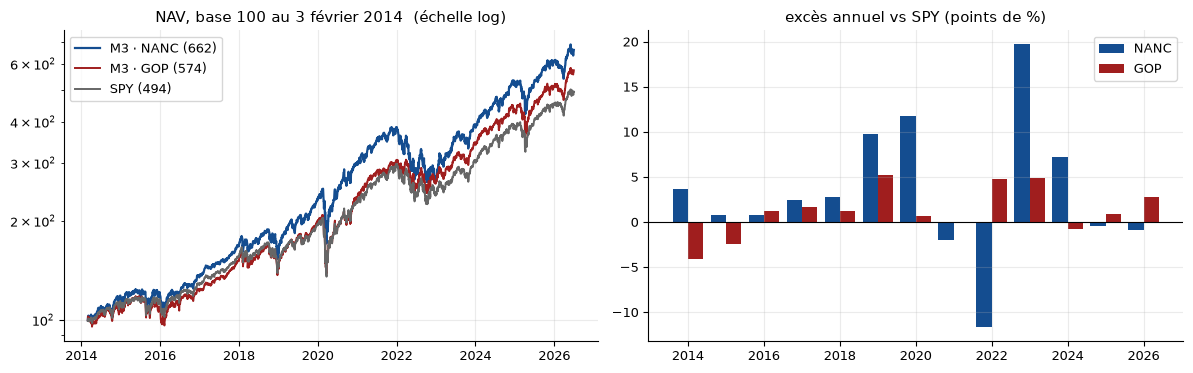

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(M3["NANC"].index, M3["NANC"], color=BLEU,  lw=1.6, label=f"M3 · NANC ({M3['NANC'].iloc[-1]:.0f})")
ax[0].plot(M3["GOP"].index,  M3["GOP"],  color=ROUGE, lw=1.4, label=f"M3 · GOP ({M3['GOP'].iloc[-1]:.0f})")
ax[0].plot(nav_spy_m3.index, nav_spy_m3, color=GRIS,  lw=1.4, label=f"SPY ({nav_spy_m3.iloc[-1]:.0f})")
ax[0].set_yscale("log"); ax[0].set_title("NAV, base 100 au 3 février 2014  (échelle log)"); ax[0].legend()
ax[1].bar(xN_.index - 0.2, xN_.values, width=0.4, color=BLEU,  label="NANC")
ax[1].bar(xG_.index + 0.2, xG_.values, width=0.4, color=ROUGE, label="GOP")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("excès annuel vs SPY (points de %)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_nav.png", dpi=150, bbox_inches="tight"); plt.show()

In [28]:
i_fin = coupes[-2]
lignes, tops = [], {}
for nom in ["NANC", "GOP"]:
    w = 100 * pd.Series(WPM[("M3 · $ × élus", nom)][i_fin]).sort_values(ascending=False)
    mx, t5, ne = conc(w)
    n_cap = int((w > 100*CAP - 1e-9).sum())            # combien de lignes touchent effectivement le plafond
    lignes.append({"fonds": nom, "titres": len(w), "plus gros poids %": mx, "top-5 %": t5, "N_eff": ne,
                   "lignes au plafond": n_cap})
    tops[nom] = w.head(10).round(2)
display(pd.DataFrame(lignes).set_index("fonds"))
print(f"\ntop-10 à la coupe du {cal[i_fin].date()} :")
display(pd.DataFrame(tops).fillna(""))
print("\nnombre de lignes au plafond, en médiane sur toutes les coupes :")
for nom in ["NANC", "GOP"]:
    m = np.median([sum(1 for x in w.values() if x > CAP - 1e-9)
                   for w in WPM[("M3 · $ × élus", nom)].values() if w])
    print(f"   {nom} : {m:.0f}")

,titres,plus gros poids %,top-5 %,N_eff,lignes au plafond
fonds,,,,,
NANC,150,10.0,42.2,21.6,1
GOP,150,9.0,32.6,32.7,0



top-10 à la coupe du 2026-05-29 :


,NANC,GOP
AAPL,6.34,8.26
AMD,,2.15
AMZN,7.94,3.22
AVGO,6.07,
COP,,1.98
GOOG,9.95,4.19
META,3.28,3.68
MSFT,7.92,8.98
NFLX,1.39,
NVDA,10.0,6.39



nombre de lignes au plafond, en médiane sur toutes les coupes :
   NANC : 2
   GOP : 1


### §6.2 — Non-régression : la référence, avant tout test

Deux ancres. La première est M3 sur les titres, telle que le notebook 13 la publie. La seconde est la
version ETF actuelle — celle que ce notebook doit **battre**, et qu'il faut donc reproduire exactement
avant d'essayer quoi que ce soit.

In [29]:
# ── la carte titre → ETF sectoriel, telle que le notebook 13 la construit (§12.3) ──
_tkm  = df.tk.map(lambda t: FUSION.get(t, t))
CARTE = df.assign(tkm=_tkm).groupby("tkm").etf_proxy.agg(lambda s: s.mode().iat[0])

def poids_agrege(i1, parti, carte=None, cap_sect=None, **kw):
    # M3 EN ENTIER, puis on remplace chaque ligne par son ETF et on somme les POIDS.
    # C'est la spécification « seul l'instrument change ». Rien d'autre ne bouge.
    carte = CARTE if carte is None else carte
    w = poids_methode(i1, parti, **kw)
    if not w: return {}
    s = pd.Series(w); cle = carte.reindex(s.index)
    assert not cle.isna().any(), f"coupe {i1} : titres sans instrument — {list(s.index[cle.isna()])}"
    s = s.groupby(cle.values).sum()
    viv = [t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]
    if not viv or s[viv].sum() <= 0: return {}
    s = s[viv] / s[viv].sum()                       # renormalisation sur les instruments cotés
    if cap_sect is not None: s = cap_poids(s, cap_sect)
    return s.to_dict()

def rotation(WP, tau_max=np.inf, cuts=None):
    # rotation RÉALISÉE, telle que le moteur la produit — définition du §9 du notebook 13, reprise ici
    cuts = coupes if cuts is None else cuts
    _, tr = run_livre(WP, tau_max, cuts=cuts)
    idx = pd.DatetimeIndex([cal[cuts[j]+1] for j in range(1, len(cuts)-1)][:len(tr)])
    s   = pd.Series(tr, index=idx)
    n   = s.groupby(s.index.year).size()
    return s, 100*s.groupby(s.index.year).sum()[n[n >= 6].index]     # années complètes seulement

COUT_BPS = 10.0                              # pb par aller-retour — même valeur qu'au notebook 13

REF, ANC = {}, []
for parti, nom in PARTIS:
    REF[("M3 · titres", nom)]  = SER[("M3 · $ × élus", nom)]
    WP = {i: poids_agrege(i, parti) for i in coupes[:-1]}
    REF[("V2 · 11 secteurs", nom)] = run_livre(WP, np.inf)[0]

for k, V in REF.items():
    b = bilan_ic(V, f"{k[0]} — {k[1]}")
    V19 = V[V.index >= pd.Timestamp("2019-01-01")]
    ANC.append({"run": f"{k[0]} — {k[1]}", "excès 2014+ %/an": b["excès %/an"], "t": b["t"],
                "excès 2019+ %/an": bilan(V19, f"{k[0]} — {k[1]} (2019+)")["excès %/an"],
                "NAV": b["NAV"]})
display(pd.DataFrame(ANC).set_index("run").round(2))

assert abs(REF[("M3 · titres", "NANC")].iloc[-1] - 661.57) < 0.01, "M3 NANC a bougé"
assert abs(REF[("M3 · titres", "GOP")].iloc[-1]  - 573.57) < 0.01, "M3 GOP a bougé"
assert abs(REF[("V2 · 11 secteurs", "NANC")].iloc[-1] - 565.34) < 0.05, "la version ETF a bougé"
assert abs(REF[("V2 · 11 secteurs", "GOP")].iloc[-1]  - 530.37) < 0.05, "la version ETF a bougé"
print("\n✅ les deux références sont reproduites — M3 (661,57 / 573,57) et la V2 à 11 secteurs (565,34 / 530,37)")

,excès 2014+ %/an,t,excès 2019+ %/an,NAV
run,,,,
M3 · titres — NANC,3.40,1.61,4.16,661.57
V2 · 11 secteurs — NANC,1.50,1.38,1.92,565.34
M3 · titres — GOP,1.24,1.61,2.28,573.57
V2 · 11 secteurs — GOP,0.45,0.57,1.12,530.37



✅ les deux références sont reproduites — M3 (661,57 / 573,57) et la V2 à 11 secteurs (565,34 / 530,37)


---
# §2 — Y a-t-il seulement de l'information au niveau sectoriel ?

**Ce test passe en premier parce qu'il peut rendre tout le reste inutile.** Toutes les constructions qui
suivent supposent que *savoir quels secteurs les élus achètent* dit quelque chose sur *ce que ces secteurs
vont faire*. On le vérifie directement, sans passer par un portefeuille — donc sans que le résultat dépende
d'un plafond, d'une sélection ou d'une pondération.

**La forme.** À chaque coupe $t$ et pour chaque secteur $S$, on confronte le **poids que le signal donne au
secteur** au **rendement de ce secteur le mois suivant**, l'un et l'autre pris **en écart à leur moyenne du
mois** :

$$\tilde r^{S}_{t\to t+1} \;=\; b\,\tilde w^{S}_{t} \;+\; \varepsilon_{S,t},
\qquad \tilde x^{S}_t \equiv x^{S}_t - \tfrac{1}{11}\textstyle\sum_{S'} x^{S'}_t$$

Ce dé-moyennage par date — l'estimateur *within* — est ce qui rend le test honnête : il **absorbe
entièrement** le mouvement commun du mois, quel qu'il soit. Sans lui, on mesurerait surtout que les secteurs
montent quand le marché monte. Il a deux avantages sur le fait de retrancher un indice construit : il ne
dépend d'**aucune** estimation des poids du marché, et il utilise donc **les 148 coupes** au lieu des 77 où
ces poids existent.

**Ce qu'on lit.** $b > 0$ et significatif $\Rightarrow$ un secteur que le signal surpondère sur-performe
effectivement les autres le mois suivant : l'information existe, et il vaut la peine de l'exprimer en
portefeuille. $b \approx 0 \Rightarrow$ il n'y en a pas, et aucune pondération ne la fera apparaître.

⚠️ **Les erreurs-types sont groupées par date** : les onze secteurs d'un même mois ne sont pas des
observations indépendantes, et les traiter comme telles gonflerait le $t$.

In [30]:
D19 = pd.Timestamp("2019-01-01")

# ── les rendements mensuels de chaque secteur, d'une coupe à la suivante ──
def rendements_coupes(instruments, cuts):
    R = {}
    for j in range(len(cuts) - 1):
        e, e2 = cuts[j] + 1, cuts[j+1] + 1
        for t in instruments:
            if t in PXV and np.isfinite(PXV[t][e]) and np.isfinite(PXV[t][e2]) and PXV[t][e] > 0:
                R[(cal[cuts[j]], t)] = PXV[t][e2] / PXV[t][e] - 1
    return pd.Series(R).rename("r")

r_sect = rendements_coupes(ETF_SECT, coupes)

# ── le pari actif du signal, coupe par coupe : poids du portefeuille agrégé moins poids du marché ──
BM_AN = {}                                  # poids du marché par année (régression contrainte, §12.5 du nb13)
from scipy.optimize import lsq_linear
RS = pd.DataFrame({t: pd.Series(PXV[t], index=cal).pct_change() for t in ETF_SECT})
for a in sorted({d.year for d in cal if d.year >= 2019 and d.year <= cal[-1].year - 1}):
    idx = [d for d in cal if d.year == a]
    d = pd.concat([RS.reindex(idx), r_spy.reindex(idx).rename("m")], axis=1).dropna()
    R, y = d[ETF_SECT].values, d["m"].values
    K = 1e3 * np.abs(R).max()
    A = np.vstack([R, K*np.ones((1, R.shape[1]))]); b_ = np.concatenate([y, [K]])
    BM_AN[a] = pd.Series(lsq_linear(A, b_, bounds=(0, np.inf)).x, index=ETF_SECT)
print(f"poids du marché reconstruits pour {len(BM_AN)} années : {min(BM_AN)}–{max(BM_AN)}")

poids du marché reconstruits pour 7 années : 2019–2025


In [31]:
# ── le panel : une ligne par (fonds, coupe, secteur) ──
PAN = []
for parti, nom in PARTIS:
    for i1 in coupes[:-1]:
        w = poids_agrege(i1, parti)
        if not w: continue
        wS = pd.Series(w).reindex(ETF_SECT).fillna(0.0)
        for S in ETF_SECT:
            if (cal[i1], S) in r_sect.index:
                PAN.append({"fonds": nom, "date": cal[i1], "secteur": S,
                            "w": wS[S], "r_sect": r_sect[(cal[i1], S)]})
PAN = pd.DataFrame(PAN)

# le dé-moyennage PAR (fonds, date) : c'est lui qui absorbe le mouvement commun du mois
g = PAN.groupby(["fonds", "date"])
PAN["w_c"] = PAN.w      - g.w.transform("mean")
PAN["r_c"] = PAN.r_sect - g.r_sect.transform("mean")
display(PAN.head())
print(f"panel : {len(PAN):,} lignes · {PAN.date.nunique()} coupes · {PAN.secteur.nunique()} secteurs · 2 fonds")
assert abs(PAN.groupby(["fonds","date"]).w_c.sum()).max() < 1e-12, "le dé-moyennage des poids a échoué"
print("✅ à chaque date, les écarts de poids somment à zéro : le mouvement commun est bien retiré")

,fonds,date,secteur,w,r_sect,w_c,r_c
0,NANC,2014-02-28,XLB,0.022028,0.016178,-0.089083,-0.006235
1,NANC,2014-02-28,XLE,0.008811,0.033765,-0.102300,0.011352
2,NANC,2014-02-28,XLF,0.283435,0.043331,0.172324,0.020918
3,NANC,2014-02-28,XLI,0.233219,0.023586,0.122108,0.001172
4,NANC,2014-02-28,XLK,0.200284,0.027203,0.089172,0.004790


panel : 3,112 lignes · 148 coupes · 11 secteurs · 2 fonds
✅ à chaque date, les écarts de poids somment à zéro : le mouvement commun est bien retiré


In [32]:
def panel_within(d, xcol="w_c", ycol="r_c"):
    # régression SANS constante sur les variables dé-moyennées (estimateur within),
    # erreurs-types GROUPÉES PAR DATE — les 11 secteurs d'un mois ne sont pas indépendants
    x, y = d[xcol].values, d[ycol].values
    b = float((x @ y) / (x @ x))
    e = y - b*x
    meat = sum(float((xg * eg).sum())**2
               for (_, gg) in d.assign(e=e).groupby("date")
               for xg, eg in [(gg[xcol].values, gg.e.values)])
    se = np.sqrt(meat) / (x @ x)
    return {"b": b, "t (groupé)": b/se, "n obs": len(d), "n coupes": d.date.nunique(),
            "R² within": 1 - float(e @ e)/float(y @ y)}

T = []
for nom in ["NANC", "GOP"]:
    for lab, sub in [("2014-2026 (tout)", PAN[PAN.fonds == nom]),
                     ("2019-2026", PAN[(PAN.fonds == nom) & (PAN.date >= D19)])]:
        o = panel_within(sub); o["fonds"] = nom; o["fenêtre"] = lab; T.append(o)
RES = pd.DataFrame(T).set_index(["fonds", "fenêtre"])[["b", "t (groupé)", "R² within", "n obs", "n coupes"]]
display(RES.round(4))

print("\nlecture : b est le rendement relatif du mois suivant, par point de surpondération.")
print("Un b de 0,10 dit qu'un secteur surpondéré de 10 points sur-performe les autres de 1,0 % le mois d'après.")
print(f"\n|t| maximal (groupé par date) : {RES['t (groupé)'].abs().max():.2f} — seuil usuel 1,96")
print("⚠️ si b n'est pas distinguable de zéro, aucune pondération sur onze lignes n'y changera rien :")
print("   ce ne serait pas la forme du portefeuille qui est en cause, ce serait le signal lui-même.")

b  t (groupé)  R² within  n obs  n coupes
fonds fenêtre                                                         
NANC  2014-2026 (tout)  0.0297      1.9004     0.0063   1556       148
      2019-2026         0.0323      1.4682     0.0066    979        89
GOP   2014-2026 (tout)  0.0391      2.0597     0.0068   1556       148
      2019-2026         0.0510      1.9000     0.0102    979        89


lecture : b est le rendement relatif du mois suivant, par point de surpondération.
Un b de 0,10 dit qu'un secteur surpondéré de 10 points sur-performe les autres de 1,0 % le mois d'après.

|t| maximal (groupé par date) : 2.06 — seuil usuel 1,96
⚠️ si b n'est pas distinguable de zéro, aucune pondération sur onze lignes n'y changera rien :
   ce ne serait pas la forme du portefeuille qui est en cause, ce serait le signal lui-même.


In [33]:
# De combien le signal bouge-t-il d'un mois à l'autre ? (descriptif — il commande la suite)
for nom in ["NANC", "GOP"]:
    d = PAN[PAN.fonds == nom].pivot_table(index="date", columns="secteur", values="w")
    dd = d.diff().abs().sum(axis=1) / 2
    rho = d.corrwith(d.shift(), axis=1).mean()
    print(f"{nom} : d'une coupe à la suivante, {100*dd.mean():.1f} % du portefeuille change de main · "
          f"corrélation des poids entre deux coupes consécutives {rho:.3f}")
print("\n→ un portefeuille sectoriel bouge PEU d'un mois à l'autre : le signal est stable par nature,")
print("  ce qui oriente d'emblée vers une inclinaison à tenir plutôt que vers des rotations à capter.")

NANC : d'une coupe à la suivante, 2.2 % du portefeuille change de main · corrélation des poids entre deux coupes consécutives 0.995
GOP : d'une coupe à la suivante, 2.3 % du portefeuille change de main · corrélation des poids entre deux coupes consécutives 0.991

→ un portefeuille sectoriel bouge PEU d'un mois à l'autre : le signal est stable par nature,
  ce qui oriente d'emblée vers une inclinaison à tenir plutôt que vers des rotations à capter.


### §2.1 — De quoi ce signal est-il fait : une inclinaison, ou des rotations ?

Le signal existe. Reste à savoir **par quoi il agit**, parce que les deux réponses possibles ne se livrent
pas du tout de la même façon :

- une **inclinaison permanente** — le portefeuille surpondère toujours les mêmes secteurs. Elle se tient
  avec une allocation **fixe** : pas de rotation, pas de coûts, très simple à intégrer ;
- des **rotations** — le portefeuille change de secteur au bon moment. Cela exige de **recomposer** chaque
  mois, donc de payer la rotation.

On sépare les deux mécaniquement : en retirant à chaque secteur **sa propre moyenne** (en plus de celle du
mois), il ne reste dans le signal que ce qui **varie**.

$$\ddot r^{S}_{t+1} \;=\; b_{\text{rotation}}\;\ddot w^{S}_{t} + \varepsilon,
\qquad \ddot x^{S}_t = x^{S}_t - \bar x^{S}_{\bullet} - \bar x^{\bullet}_{t} + \bar x^{\bullet}_{\bullet}$$

La comparaison des deux $b$ dit **où porter l'effort** : sur le choix des secteurs, ou sur le moment.

In [34]:
# effets fixes DATE et SECTEUR : il ne reste que ce qui varie dans le temps, secteur par secteur
PAN["w_cc"], PAN["r_cc"] = np.nan, np.nan
for nom in ["NANC", "GOP"]:
    m = PAN.fonds == nom
    d = PAN[m]
    for col, src in [("w_cc", "w"), ("r_cc", "r_sect")]:
        x = d[src]
        PAN.loc[m, col] = (x - d.groupby("secteur")[src].transform("mean")
                             - d.groupby("date")[src].transform("mean") + x.mean()).values

T2 = []
for nom in ["NANC", "GOP"]:
    d = PAN[PAN.fonds == nom]
    o1 = panel_within(d, "w_c",  "r_c");  o1.update(fonds=nom, modèle="le signal entier")
    o2 = panel_within(d, "w_cc", "r_cc"); o2.update(fonds=nom, modèle="sa part qui VARIE (rotations)")
    T2 += [o1, o2]
R2 = pd.DataFrame(T2).set_index(["fonds", "modèle"])[["b", "t (groupé)", "R² within", "n obs"]]
display(R2.round(4))

print("\nde quoi le signal est fait, en variance :")
for nom in ["NANC", "GOP"]:
    d = PAN[PAN.fonds == nom]
    v_tot  = float(d.w_c.var())
    v_perm = float(d.groupby("secteur").w_c.mean().reindex(d.secteur).var())
    print(f"  {nom} : inclinaison PERMANENTE {100*v_perm/v_tot:.0f} % · "
          f"rotations {100*(1-v_perm/v_tot):.0f} %")
print("\n→ CE QUE ÇA ORIENTE : l'essentiel du signal sectoriel est une INCLINAISON, pas une rotation.")
print("  La piste à suivre est donc une allocation inclinée — et deux leviers restent à essayer :")
print("  élargir l'univers (§3), pour que l'inclinaison soit plus fine que « la tech » ;")
print("  et débarrasser le score de l'effet taille (§4), pour que l'inclinaison dise autre chose")
print("  que le poids des secteurs dans l'indice.")

b  t (groupé)  R² within  n obs
fonds modèle                                                             
NANC  le signal entier               0.0297      1.9004     0.0063   1556
      sa part qui VARIE (rotations)  0.0195      0.6089     0.0004   1556
GOP   le signal entier               0.0391      2.0597     0.0068   1556
      sa part qui VARIE (rotations)  0.0459      1.2638     0.0022   1556


de quoi le signal est fait, en variance :
  NANC : inclinaison PERMANENTE 85 % · rotations 15 %
  GOP : inclinaison PERMANENTE 76 % · rotations 24 %

→ CE QUE ÇA ORIENTE : l'essentiel du signal sectoriel est une INCLINAISON, pas une rotation.
  La piste à suivre est donc une allocation inclinée — et deux leviers restent à essayer :
  élargir l'univers (§3), pour que l'inclinaison soit plus fine que « la tech » ;
  et débarrasser le score de l'effet taille (§4), pour que l'inclinaison dise autre chose
  que le poids des secteurs dans l'indice.


In [35]:
# CE QUE ÇA VAUT — traduction du b en points de rendement annuel, pour fixer les idées
print("ce que le signal rapporte, sur le portefeuille tel qu'on le tient aujourd'hui :\n")
for nom in ["NANC", "GOP"]:
    d = PAN[PAN.fonds == nom]
    b  = panel_within(d, "w_c", "r_c")["b"]
    bt = panel_within(d, "w_cc", "r_cc")["b"]
    q  = d.groupby("date").w_c.apply(lambda s: float((s**2).sum())).mean()
    qt = d.groupby("date").w_cc.apply(lambda s: float((s**2).sum())).mean()
    print(f"  {nom} : signal entier Σ(Δw)² = {q:.4f} → {100*12*b*q:+.2f} %/an   |   "
          f"part qui varie Σ(Δẅ)² = {qt:.4f} → {100*12*bt*qt:+.2f} %/an")
print("\n(l'excès effectivement mesuré du portefeuille agrégé vaut +1,50 et +0,45 %/an —")
print(" l'écart entre les deux est ce que la FORME du portefeuille laisse sur la table, §5.)")

ce que le signal rapporte, sur le portefeuille tel qu'on le tient aujourd'hui :

  NANC : signal entier Σ(Δw)² = 0.0934 → +3.33 %/an   |   part qui varie Σ(Δẅ)² = 0.0140 → +0.33 %/an
  GOP : signal entier Σ(Δw)² = 0.0583 → +2.74 %/an   |   part qui varie Σ(Δẅ)² = 0.0137 → +0.76 %/an

(l'excès effectivement mesuré du portefeuille agrégé vaut +1,50 et +0,45 %/an —
 l'écart entre les deux est ce que la FORME du portefeuille laisse sur la table, §5.)


---
# §3 — Élargir l'univers : de onze secteurs à une trentaine d'ETF

**Pourquoi c'est le premier levier.** Les trois faiblesses de la version à onze lignes ont la même racine —
*onze lignes, c'est trop peu* : la sélection ne coupe rien ($11 < 150$), le consensus ne discrimine plus
(un élu qui achète trois titres d'un secteur n'y compte qu'une fois), et le plafond n'a plus de marge
($11\times10\,\% = 110\,\%$). Descendre d'un cran en granularité les corrige **toutes les trois d'un coup**.

**Ce qui rend l'opération possible sans rien acheter** : le cache de prix contient déjà **67 ETF sectoriels
et thématiques**, la plupart cotés depuis 2012 — semi-conducteurs, biotechnologie, défense, banques
régionales, logiciel, immobilier, or, métaux, transport, distribution… Il ne manquait qu'une chose : savoir
**dans quelle industrie** chaque titre se range. Le dépôt n'a que le secteur GICS, à onze valeurs. On est
donc allé chercher l'industrie auprès de la même source qui a servi à établir les secteurs.

### Les trois règles, écrites avant le premier backtest
1. **Un ETF n'entre dans l'univers que s'il cote au plus tard le 01/01/2013**, c'est-à-dire avant le début
   du backtest. Cela écarte d'emblée les thématiques récentes (cybersécurité 2014-2015, robotique 2016,
   infrastructures 2017) : les faire entrer reviendrait à choisir l'univers en connaissant l'histoire.
2. **La carte va de l'industrie vers l'ETF, jamais du titre vers l'ETF.** On ne décide jamais ligne par
   ligne : une industrie entière est rattachée à un instrument, ou elle retombe sur son secteur.
3. **Tout ce qui n'est pas rattaché retombe sur le SPDR de son secteur.** Aucun titre n'est perdu, et
   l'univers reste une partition exacte du même flux — c'est ce qui rend les deux versions comparables.

⚠️ **Ce que la carte n'est pas** : les industries viennent d'une taxonomie propriétaire (~136 valeurs),
qui n'est pas la sous-industrie GICS. Elle sert de **clé de regroupement**, pas de vérité de classification.

In [36]:
import json
FINE = f"{RACINE}/00. S3S4 en cours/cache/sector_fine_v1/industry.json"
IND  = {k: (v.get("industry") or None) for k, v in json.load(open(FINE, encoding="utf-8")).items()}
print(f"industries récupérées : {sum(v is not None for v in IND.values()):,} titres · "
      f"{len({v for v in IND.values() if v})} industries distinctes")

# ── LA CARTE, déclarée ici et pas ailleurs : industrie → ETF ──────────────────────────────
# Chaque ETF cité cote depuis 2012 ; la règle 1 (inception ≤ 2013) est assertée plus bas.
CARTE_IND = {
  # technologie
  "XSD":  ["Semiconductors", "Semiconductor Equipment & Materials"],
  "IGV":  ["Software - Application", "Software - Infrastructure", "Information Technology Services"],
  "FDN":  ["Internet Content & Information"],
  # santé
  "XBI":  ["Biotechnology"],
  "IHI":  ["Medical Devices", "Medical Instruments & Supplies"],
  "IHF":  ["Healthcare Plans", "Medical Care Facilities", "Medical Distribution"],
  # finance
  "KRE":  ["Banks - Regional"],
  "KBE":  ["Banks - Diversified"],
  "KIE":  ["Insurance - Life", "Insurance - Property & Casualty", "Insurance - Specialty",
           "Insurance Brokers", "Insurance - Diversified", "Insurance - Reinsurance"],
  "IAI":  ["Capital Markets", "Asset Management", "Financial Data & Stock Exchanges"],
  # immobilier — VNQ cote depuis 2012, là où XLRE ne commence qu'en octobre 2015
  "VNQ":  ["REIT - Specialty", "REIT - Industrial", "REIT - Retail", "REIT - Residential",
           "REIT - Office", "REIT - Healthcare Facilities", "REIT - Hotel & Motel",
           "REIT - Diversified", "REIT - Mortgage", "Real Estate Services",
           "Real Estate - Development", "Real Estate - Diversified"],
  # industrie
  "ITA":  ["Aerospace & Defense"],
  "IYT":  ["Railroads", "Trucking", "Integrated Freight & Logistics", "Marine Shipping", "Airlines"],
  # énergie
  "AMLP": ["Oil & Gas Midstream"],
  "OIH":  ["Oil & Gas Equipment & Services", "Oil & Gas Drilling"],
  # matériaux
  "GDX":  ["Gold", "Silver", "Other Precious Metals & Mining"],
  "XME":  ["Steel", "Copper", "Aluminum", "Industrial Metals & Mining",
           "Other Industrial Metals & Mining", "Coking Coal", "Thermal Coal"],
  # consommation
  "XHB":  ["Residential Construction", "Building Products & Equipment"],
  "XRT":  ["Specialty Retail", "Apparel Retail", "Internet Retail", "Department Stores",
           "Home Improvement Retail", "Auto & Truck Dealerships", "Luxury Goods",
           "Footwear & Accessories", "Apparel Manufacturing", "Discount Stores"],
  "PEJ":  ["Restaurants", "Resort & Casinos", "Lodging", "Travel Services", "Gambling",
           "Leisure", "Entertainment"],
  "PBJ":  ["Packaged Foods", "Beverages - Non-Alcoholic", "Beverages - Wineries & Distilleries",
           "Beverages - Brewers", "Farm Products", "Confectioners", "Food Distribution"],
}
IND2ETF = {ind: etf for etf, inds in CARTE_IND.items() for ind in inds}
print(f"carte déclarée : {len(CARTE_IND)} ETF fins couvrant {len(IND2ETF)} industries")

industries récupérées : 2,115 titres · 142 industries distinctes
carte déclarée : 21 ETF fins couvrant 80 industries


In [37]:
# ── charger les prix des ETF de la carte qui ne sont pas déjà là ──
# Le §1.3 ne charge que les titres du flux et les 11 SPDR ; les ETF fins doivent être ajoutés ici.
# ⚠️ `df` a été figé au §1.3 : ajouter des séries APRÈS ne peut donc faire entrer aucune ligne
#    dans le flux. C'est asserté juste en dessous.
n_avant = len(df)
for tk in sorted(CARTE_IND):
    if tk in PXV: continue
    s = pd.read_csv(f"{PX}/{tk}.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    assert len(s) >= 30 and s.min() >= 0.10, f"{tk} : série inexploitable"
    LAST[tk]   = s.index[-1]
    PXV[tk]    = s.reindex(cal).ffill().to_numpy()
    NFIRST[tk] = int(np.argmax(~np.isnan(PXV[tk])))
    NLAST[tk]  = cal.searchsorted(LAST[tk], side="right") - 1
assert len(df) == n_avant, "le flux a changé — l'ajout de prix ne doit rien faire entrer"
print(f"prix chargés pour les {len(CARTE_IND)} ETF de la carte · flux inchangé ({len(df):,} opérations)")

# ── RÈGLE 1 : tout ETF de la carte doit coter avant le début du backtest ──
DEB_MAX = pd.Timestamp("2013-01-01")
tard = {e: cal[NFIRST[e]].date() for e in CARTE_IND if cal[NFIRST[e]] > DEB_MAX}
assert not tard, f"ETF cotant après le 01/01/2013 — la règle 1 les interdit : {tard}"
print(f"✅ règle 1 : les {len(CARTE_IND)} ETF fins cotent tous avant le {DEB_MAX.date()}")
print("   " + " · ".join(f"{e} {cal[NFIRST[e]].year}" for e in sorted(CARTE_IND)))

# ── LA CARTE FINALE : titre → instrument (ETF fin si l'industrie est rattachée, sinon son SPDR) ──
_tk_post = df.tk.map(lambda t: FUSION.get(t, t))
CARTE_FINE = {}
for tk_post, secteur in CARTE.items():
    ind = IND.get(tk_post)
    CARTE_FINE[tk_post] = IND2ETF.get(ind, secteur) if ind else secteur
CARTE_FINE = pd.Series(CARTE_FINE)
assert set(CARTE_FINE.index) == set(CARTE.index), "les deux cartes ne portent pas les mêmes titres"

# ── ce que ça donne, pondéré par le dollar acheté (la seule pondération qui compte) ──
usd = df[df.op == "buy"].assign(tkm=_tk_post).groupby("tkm").A.sum()
rec = pd.DataFrame({"instrument": CARTE_FINE, "usd": usd.reindex(CARTE_FINE.index).fillna(0)})
res = rec.groupby("instrument").agg(titres=("usd", "size"), usd=("usd", "sum")).sort_values("usd", ascending=False)
res["part %"] = 100 * res.usd / res.usd.sum()
res["type"] = ["SPDR de secteur" if i in ETF_SECT else "ETF fin" for i in res.index]
display(res.round(1))
print(f"\nunivers : {len(res)} instruments ({(res.type=='ETF fin').sum()} fins + "
      f"{(res.type=='SPDR de secteur').sum()} secteurs) contre 11 auparavant")
print(f"part du dollar acheté qui atterrit sur un ETF FIN : "
      f"{res.loc[res.type=='ETF fin','part %'].sum():.1f} %")
print(f"titres sans industrie connue (retombés sur leur secteur) : "
      f"{sum(1 for t in CARTE_FINE.index if not IND.get(t))} sur {len(CARTE_FINE)}")

prix chargés pour les 21 ETF de la carte · flux inchangé (113,369 opérations)
✅ règle 1 : les 21 ETF fins cotent tous avant le 2013-01-01
   AMLP 2012 · FDN 2012 · GDX 2012 · IAI 2012 · IGV 2012 · IHF 2012 · IHI 2012 · ITA 2012 · IYT 2012 · KBE 2012 · KIE 2012 · KRE 2012 · OIH 2012 · PBJ 2012 · PEJ 2012 · VNQ 2012 · XBI 2012 · XHB 2012 · XME 2012 · XRT 2012 · XSD 2012


,titres,usd,part %,type
instrument,,,,
IGV,157,206670922.0,12.9,ETF fin
XLI,292,131352426.0,8.2,SPDR de secteur
XLV,163,94443989.0,5.9,SPDR de secteur
XSD,54,91941015.5,5.7,ETF fin
XRT,109,89657249.0,5.6,ETF fin
IAI,107,89461218.5,5.6,ETF fin
KIE,77,85225457.0,5.3,ETF fin
PEJ,75,71217326.5,4.4,ETF fin
XLK,161,64633105.5,4.0,SPDR de secteur



univers : 32 instruments (21 fins + 11 secteurs) contre 11 auparavant
part du dollar acheté qui atterrit sur un ETF FIN : 64.2 %
titres sans industrie connue (retombés sur leur secteur) : 663 sur 2751


### §3.1 — Rejouer M3 à l'identique sur ce nouvel univers

**Rien d'autre ne change** : même score $B_i \times m_i$, même fenêtre de trois ans, même top-150, même
plafond par titre, même exécution au close J+1. Seule la clé d'agrégation est plus fine.

In [38]:
V3, WP3 = {}, {}
for parti, nom in PARTIS:
    WP3[nom] = {i: poids_agrege(i, parti, carte=CARTE_FINE) for i in coupes[:-1]}
    V3[nom]  = run_livre(WP3[nom], np.inf)[0]

# ── CONTRÔLE DE DÉGRADATION : avec la carte GROSSIÈRE, on doit retrouver la V2 exactement ──
for parti, nom in PARTIS:
    Vc = run_livre({i: poids_agrege(i, parti, carte=CARTE) for i in coupes[:-1]}, np.inf)[0]
    assert abs(Vc.iloc[-1] - REF[("V2 · 11 secteurs", nom)].iloc[-1]) < 1e-9, f"{nom} : dégradation cassée"
print("✅ avec la carte à 11 secteurs, la construction reproduit exactement la V2 — seul l'univers a changé\n")

# les trois versions, avec leurs jeux de poids, pour que la table se lise sans détour
PARTI = {"NANC": "Democrat", "GOP": "Republican"}
JEUX = {}
for nom in ["NANC", "GOP"]:
    JEUX[("M3 · titres", nom)]      = (REF[("M3 · titres", nom)], WPM[("M3 · $ × élus", nom)])
    JEUX[("V2 · 11 secteurs", nom)] = (REF[("V2 · 11 secteurs", nom)],
                                       {i: poids_agrege(i, PARTI[nom], carte=CARTE) for i in coupes[:-1]})
    JEUX[(f"V3 · {len(res)} instruments", nom)] = (V3[nom], WP3[nom])

L = []
for (lab, nom), (V, WP) in JEUX.items():
    b   = bilan_ic(V, f"{lab} — {nom}")
    V19 = V[V.index >= D19]
    w   = 100 * pd.Series(WP[coupes[-2]]).sort_values(ascending=False)
    mx, t5, ne = conc(w)
    _, an = rotation(WP)
    L.append({"run": f"{lab} — {nom}", "excès 2014+ %/an": b["excès %/an"], "t": b["t"],
              "excès 2019+ %/an": bilan(V19, f"{lab} — {nom} (2019+)")["excès %/an"],
              "α₁ %/an": b["α %/an"], "β": b["β"], "lignes": len(w), "plus gros %": mx,
              "N_eff": ne, "rotation %/an": an.mean(), "NAV": b["NAV"]})
display(pd.DataFrame(L).set_index("run").round(2))
print("→ la ligne à lire est V3 contre V2 : même méthode, même flux, seul l'univers change.")

✅ avec la carte à 11 secteurs, la construction reproduit exactement la V2 — seul l'univers a changé



,excès 2014+ %/an,t,excès 2019+ %/an,α₁ %/an,β,lignes,plus gros %,N_eff,rotation %/an,NAV
run,,,,,,,,,,
M3 · titres — NANC,3.40,1.61,4.16,1.66,1.08,150,10.0,21.6,71.80,661.57
V2 · 11 secteurs — NANC,1.50,1.38,1.92,0.30,1.05,11,46.6,3.7,30.43,565.34
V3 · 32 instruments — NANC,0.31,0.23,0.34,-1.18,1.09,26,20.4,8.3,44.08,499.19
M3 · titres — GOP,1.24,1.61,2.28,1.09,1.00,150,9.0,32.7,76.89,573.57
V2 · 11 secteurs — GOP,0.45,0.57,1.12,0.09,1.01,11,42.2,4.2,32.57,530.37
V3 · 32 instruments — GOP,-0.60,-0.52,-0.13,-1.20,1.05,27,17.2,10.9,45.01,472.80


→ la ligne à lire est V3 contre V2 : même méthode, même flux, seul l'univers change.


### §3.2 — Pourquoi l'élargissement dégrade : ce n'est pas le signal, c'est l'instrument

Le résultat est net et il va contre l'intuition. Avant d'en tirer quoi que ce soit, il faut savoir **d'où
vient la perte**. Deux causes possibles, et elles n'ont pas les mêmes conséquences :

- **le signal désigne mal les segments** — dans ce cas la granularité fine est une impasse ;
- **les instruments fins sont moins bons que les secteurs qu'ils remplacent** — dans ce cas le signal n'est
  pas en cause, et le problème est celui de l'offre d'ETF.

On tranche en comparant, **hors de toute stratégie**, chaque ETF fin au SPDR du secteur qu'il découpe.

In [39]:
PAIRES = {"XSD":"XLK","IGV":"XLK","FDN":"XLC","XBI":"XLV","IHI":"XLV","IHF":"XLV","KRE":"XLF","KBE":"XLF",
          "KIE":"XLF","IAI":"XLF","VNQ":"XLRE","ITA":"XLI","IYT":"XLI","AMLP":"XLE","OIH":"XLE",
          "GDX":"XLB","XME":"XLB","XHB":"XLY","XRT":"XLY","PEJ":"XLY","PBJ":"XLP"}
i0, i1 = coupes[0] + 1, coupes[-1]
def cagr_px(tk):
    v = PXV[tk][i0:i1+1]; v = v[np.isfinite(v)]
    return 100*((v[-1]/v[0])**(252/len(v)) - 1)

T = pd.DataFrame([{"ETF fin": f, "%/an": cagr_px(f), "son secteur": s, "%/an (secteur)": cagr_px(s),
                   "écart pt/an": cagr_px(f) - cagr_px(s)} for f, s in PAIRES.items()]
                 ).sort_values("écart pt/an").set_index("ETF fin")
display(T.round(2))
print(f"écart médian {T['écart pt/an'].median():+.2f} pt/an · moyen {T['écart pt/an'].mean():+.2f}")
print(f"ETF fins qui BATTENT le secteur qu'ils découpent : {(T['écart pt/an']>0).sum()} sur {len(T)}")
print("\n→ LA CAUSE EST L'INSTRUMENT, PAS LE SIGNAL. Découper un secteur revient à remplacer sa moyenne")
print("  — portée par ses plus grosses capitalisations — par un segment plus étroit et plus équipondéré.")
print("  Sur une période où les méga-capitalisations ont dominé, ce remplacement coûte, indépendamment")
print("  de ce que les élus achètent. C'est le même mécanisme qu'au §12 du notebook 13 : ce qui a payé")
print("  sur cette période, c'est la CONCENTRATION, et toute subdivision la réduit.")

,%/an,son secteur,%/an (secteur),écart pt/an
ETF fin,,,,
OIH,-5.82,XLE,5.59,-11.41
IGV,14.70,XLK,22.65,-7.94
PEJ,5.99,XLY,12.09,-6.10
XRT,7.56,XLY,12.09,-4.53
KRE,7.85,XLF,11.60,-3.75
IYT,9.48,XLI,12.95,-3.47
KBE,8.66,XLF,11.60,-2.94
PBJ,6.21,XLP,8.56,-2.35
AMLP,3.91,XLE,5.59,-1.68


écart médian -0.65 pt/an · moyen -1.61
ETF fins qui BATTENT le secteur qu'ils découpent : 6 sur 21

→ LA CAUSE EST L'INSTRUMENT, PAS LE SIGNAL. Découper un secteur revient à remplacer sa moyenne
  — portée par ses plus grosses capitalisations — par un segment plus étroit et plus équipondéré.
  Sur une période où les méga-capitalisations ont dominé, ce remplacement coûte, indépendamment
  de ce que les élus achètent. C'est le même mécanisme qu'au §12 du notebook 13 : ce qui a payé
  sur cette période, c'est la CONCENTRATION, et toute subdivision la réduit.


---
# §4 — D'où vient l'excès de la version à onze secteurs ?

Avant de chercher à faire mieux, il faut savoir **ce qui paie**. L'excès d'un portefeuille sur le marché se
décompose exactement, secteur par secteur :

$$\underbrace{r^{p}_t - r^{\text{mkt}}_t}_{\text{l'excès du mois}} \;=\; \sum_{S} \underbrace{\bigl(w^{S}_t - w^{\text{mkt},S}_t\bigr)}_{\text{la surpondération}}\;\underbrace{\bigl(r^{S}_t - r^{\text{mkt}}_t\bigr)}_{\text{ce que le secteur a fait}}$$

Chaque terme dit combien un secteur a rapporté **du fait qu'on l'a surpondéré**. Si un seul secteur porte
tout, la stratégie n'est pas une stratégie sectorielle : c'est un pari sur ce secteur, et il faut le dire.

In [40]:
ATTR = {}
for nom in ["NANC", "GOP"]:
    d = PAN[PAN.fonds == nom].copy()
    an = d.date.dt.year - 1
    wM = pd.DataFrame([BM_AN[a].reindex(ETF_SECT) if a in BM_AN else pd.Series(np.nan, index=ETF_SECT)
                       for a in an], index=d.index)
    d["w_mkt"] = [wM.loc[i, s] for i, s in zip(d.index, d.secteur)]
    d = d.dropna(subset=["w_mkt"])
    d["r_mkt"] = d.date.map(d.groupby("date").apply(
        lambda g: float((g.r_sect * g.w_mkt).sum() / g.w_mkt.sum()), include_groups=False))
    d["contrib"] = (d.w - d.w_mkt) * (d.r_sect - d.r_mkt)
    ATTR[nom] = d

L = []
for nom in ["NANC", "GOP"]:
    d = ATTR[nom]
    n_ans = d.date.nunique() / 12
    g = d.groupby("secteur").agg(contrib=("contrib", "sum"),
                                 surpond=("w", "mean"), poids_mkt=("w_mkt", "mean"))
    g["contrib %/an"] = 100 * g.contrib / n_ans
    g["surpondération pt"] = 100 * (g.surpond - g.poids_mkt)
    g["fonds"] = nom
    L.append(g.sort_values("contrib %/an", ascending=False))
A = pd.concat(L).reset_index().set_index(["fonds", "secteur"])
display(A[["contrib %/an", "surpondération pt"]].round(2))

for nom in ["NANC", "GOP"]:
    g = A.loc[nom].sort_values("contrib %/an", ascending=False)
    tot = g["contrib %/an"].sum()
    print(f"{nom} : excès attribué {tot:+.2f} %/an · le plus gros contributeur est {g.index[0]} "
          f"({g['contrib %/an'].iloc[0]:+.2f} pt, soit {100*g['contrib %/an'].iloc[0]/tot:.0f} % du total)")
print("\n(l'attribution porte sur 2020-2026, la fenêtre où les poids du marché sont reconstructibles)")

contrib %/an  surpondération pt
fonds secteur                                 
NANC  XLK              0.56               5.67
      XLF              0.26               0.70
      XLV              0.21              -4.72
      XLU              0.17              -2.18
      XLP              0.15              -2.75
      XLY              0.13               1.39
      XLC              0.12               8.19
      XLRE             0.03              -0.40
      XLI             -0.01              -1.95
      XLB             -0.02              -0.72
      XLE             -0.02              -3.24
GOP   XLE              0.73               4.62
      XLF              0.40               3.82
      XLP              0.21              -2.85
      XLC              0.21               0.79
      XLY              0.20               0.93
      XLU              0.19              -1.96
      XLV              0.17              -1.94
      XLRE             0.06              -0.85
      XLK              0.04              -2.66
      XLI              0.03               0.33
      XLB             -0.06              -0.23

NANC : excès attribué +1.57 %/an · le plus gros contributeur est XLK (+0.56 pt, soit 36 % du total)
GOP : excès attribué +2.19 %/an · le plus gros contributeur est XLE (+0.73 pt, soit 34 % du total)

(l'attribution porte sur 2020-2026, la fenêtre où les poids du marché sont reconstructibles)


---
# §5 — La forme du portefeuille : *le marché, plus un tilt*

C'est la forme qu'un allocataire tient réellement, et la seule dont le risque relatif se pilote :

$$w \;=\; w^{\text{mkt}} \;+\; \lambda\,\bigl(w^{\text{signal}} - w^{\text{mkt}}\bigr)$$

$\lambda = 0$ donne le marché ; $\lambda = 1$ donne exactement la version actuelle ; $\lambda > 1$ amplifie
le pari. **$\lambda$ n'est pas optimisé** : le profil complet est publié, et $\lambda = 1$ reste la
référence. L'intérêt de cette écriture est de séparer ce qui est **gratuit** (le marché, qu'on obtient avec
un seul ETF large) de ce que le signal **ajoute** — et de rendre le tracking error explicite.

In [41]:
LAM = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
cuts_m = [i for i in coupes if cal[i].year - 1 in BM_AN]

def livre_tilt(nom, lam, carte=None):
    parti, WP = PARTI[nom], {}
    for i in cuts_m[:-1]:
        wm = BM_AN[cal[i].year - 1]
        ws = pd.Series(poids_agrege(i, parti, carte=(CARTE if carte is None else carte))
                       ).reindex(ETF_SECT).fillna(0.0)
        w  = (wm + lam*(ws - wm)).clip(lower=0)        # long seul : aucune position négative
        if w.sum() > 0: WP[i] = (w / w.sum()).to_dict()
    return WP

RESL = []
for nom in ["NANC", "GOP"]:
    for lam in LAM:
        WP = livre_tilt(nom, lam)
        V  = run_livre(WP, np.inf, cuts=cuts_m)[0]
        b  = bilan(V, f"tilt λ={lam} — {nom}")
        net = run_livre(WP, np.inf, cuts=cuts_m, cout_bps=COUT_BPS)[0]
        rp = V.pct_change().dropna(); rs = r_spy.reindex(rp.index)
        te = 100*np.sqrt(252)*(rp - rs).std()
        _, an = rotation(WP, cuts=cuts_m)
        RESL.append({"fonds": nom, "λ": lam, "excès %/an": b["excès %/an"],
                     "excès NET %/an": bilan(net, f"tilt λ={lam} net — {nom}")["excès %/an"],
                     "t": b["t"], "α₁ %/an": b["α %/an"], "t_α₁": b["t_α"], "tracking error %/an": te,
                     "ratio d'information": b["excès %/an"]/te if te > 0 else np.nan,
                     "β": b["β"], "rotation %/an": an.mean(), "NAV": b["NAV"]})
display(pd.DataFrame(RESL).set_index(["fonds", "λ"]).round(2))
print("λ = 0 est le marché reconstruit ; λ = 1 est la version actuelle ramenée à cette fenêtre.")
print("\nTRACKING ERROR = écart-type annualisé de (portefeuille − indice). Un TE de 3 %/an signifie que")
print("deux années sur trois environ, l'écart au SPY tient entre −3 % et +3 %. C'est le budget de risque")
print("relatif : c'est LUI qu'on fixe, et λ s'en déduit — jamais l'inverse.")
print("\nRATIO D'INFORMATION = excès ÷ tracking error : combien de rendement par unité d'écart pris.")
print("C'est le seul des deux qui compare des paris d'intensités différentes. Au-dessus de 0,5, un")
print("gérant actif considère que le pari est efficace — sous réserve, ici, qu'il ne soit pas significatif.")

excès %/an  excès NET %/an     t  α₁ %/an  t_α₁  tracking error %/an  ratio d'information     β  rotation %/an     NAV
fonds λ                                                                                                                          
NANC  0.0       -0.28           -0.33 -0.26    -0.65 -0.80                 2.06                -0.14  1.00          21.28  248.75
      0.5        0.71            0.66  0.53    -0.30 -0.38                 2.13                 0.33  1.02          21.58  259.63
      1.0        1.73            1.67  0.86     0.05  0.05                 2.97                 0.58  1.05          26.22  270.69
      1.5        2.62            2.53  1.00     0.40  0.28                 3.89                 0.67  1.07          35.07  280.34
      2.0        3.27            3.17  1.05     0.65  0.39                 4.64                 0.70  1.09          42.82  287.35
      2.5        3.59            3.48  1.06     0.74  0.40                 5.15                 0.70  1.09          47.94  290.40
      3.0        3.78            3.66  1.08     0.83  0.42                 5.47                 0.69  1.10          51.67  292.57
GOP   0.0       -0.28           -0.33 -0.26    -0.65 -0.80                 2.06                -0.14  1.00          21.28  248.75
      0.5        0.71            0.65  0.66     0.27  0.28                 2.48                 0.29  1.00          23.97  265.82
      1.0        1.70            1.62  1.34     1.19  0.87                 3.45                 0.49  1.01          31.30  283.63
      1.5        2.58            2.47  1.62     2.03  1.11                 4.56                 0.57  1.02          43.19  300.35
      2.0        3.34            3.21  1.67     2.79  1.24                 5.63                 0.59  1.02          54.32  315.72
      2.5        3.86            3.71  1.59     3.40  1.29                 6.57                 0.59  1.02          62.90  327.17
      3.0        4.09            3.92  1.46     3.75  1.29                 7.25                 0.56  1.01          68.80  333.22

λ = 0 est le marché reconstruit ; λ = 1 est la version actuelle ramenée à cette fenêtre.

TRACKING ERROR = écart-type annualisé de (portefeuille − indice). Un TE de 3 %/an signifie que
deux années sur trois environ, l'écart au SPY tient entre −3 % et +3 %. C'est le budget de risque
relatif : c'est LUI qu'on fixe, et λ s'en déduit — jamais l'inverse.

RATIO D'INFORMATION = excès ÷ tracking error : combien de rendement par unité d'écart pris.
C'est le seul des deux qui compare des paris d'intensités différentes. Au-dessus de 0,5, un
gérant actif considère que le pari est efficace — sous réserve, ici, qu'il ne soit pas significatif.


---
# §6 — Ce que chaque version vaut à l'exécution

Un excès brut ne se livre pas. Ce paragraphe donne les grandeurs qu'un allocataire regarde avant tout :
ce qui reste **net de frais**, ce que le portefeuille **fait perdre au pire moment**, et ce qu'il **coûte à
tenir**. Les frais retenus sont les **10 points de base** par aller-retour déjà utilisés au notebook 13.

⚠️ **Ce tableau ne comporte aucune contrainte de Ramify** — elles ne sont pas connues. Il publie donc
**toutes** les grandeurs qu'une contrainte viendrait filtrer, de sorte que le choix final se fasse sur des
chiffres déjà disponibles.

In [42]:
def perte_max(V):
    return 100 * float((V / V.cummax() - 1).min())

def sharpe(V):
    r = V.pct_change().dropna()
    d = pd.DataFrame({"r": r}).join(FF[["RF"]]).dropna()
    x = d.r - d.RF
    return float(x.mean() / x.std() * np.sqrt(252))

CAND = {}
for nom in ["NANC", "GOP"]:
    parti = PARTI[nom]
    CAND[("M3 · 150 titres", nom)]    = (REF[("M3 · titres", nom)], WPM[("M3 · $ × élus", nom)], coupes)
    CAND[("V2 · 11 secteurs", nom)]   = (REF[("V2 · 11 secteurs", nom)],
                                         {i: poids_agrege(i, parti, carte=CARTE) for i in coupes[:-1]}, coupes)
    CAND[(f"V3 · {len(res)} instruments", nom)] = (V3[nom], WP3[nom], coupes)
    for lam in [1.0, 2.0]:
        WP = {}
        for i in cuts_m[:-1]:
            wm = BM_AN[cal[i].year - 1]
            ws = pd.Series(poids_agrege(i, parti, carte=CARTE)).reindex(ETF_SECT).fillna(0.0)
            w  = (wm + lam*(ws - wm)).clip(lower=0)
            if w.sum() > 0: WP[i] = (w / w.sum()).to_dict()
        CAND[(f"marché + tilt λ={lam:.0f}", nom)] = (run_livre(WP, np.inf, cuts=cuts_m)[0], WP, cuts_m)

EXE = []
for (lab, nom), (V, WP, cuts) in CAND.items():
    brut = bilan(V, f"{lab} — {nom}")
    net  = run_livre(WP, np.inf, cuts=cuts, cout_bps=COUT_BPS)[0]
    bn   = bilan(net, f"{lab} — {nom} (net)")
    _, an = rotation(WP, cuts=cuts)
    w = pd.Series(WP[max(WP)])
    EXE.append({"run": f"{lab} — {nom}", "lignes": len(w),
                "excès brut %/an": brut["excès %/an"], "excès NET %/an": bn["excès %/an"],
                "coût pt/an": brut["excès %/an"] - bn["excès %/an"],
                "rotation %/an": an.mean(),
                "vol %/an": 100*V.pct_change().std()*np.sqrt(252),
                "perte max %": perte_max(V), "Sharpe": sharpe(V)})
E = pd.DataFrame(EXE).set_index("run")
display(E.round(2))
sp = (1 + r_spy.reindex(REF[("M3 · titres","NANC")].index).fillna(0)).cumprod()*100
print(f"repère SPY sur 2014-2026 : vol {100*r_spy.std()*np.sqrt(252):.1f} %/an · "
      f"perte max {perte_max(sp):.1f} % · Sharpe {sharpe(sp):.2f}")
print("\n→ la colonne qui décide pour un exécutant n'est pas l'excès brut mais le COUPLE (excès net, lignes).")

,lignes,excès brut %/an,excès NET %/an,coût pt/an,rotation %/an,vol %/an,perte max %,Sharpe
run,,,,,,,,
M3 · 150 titres — NANC,150,3.40,3.23,0.17,71.80,19.14,-32.11,0.79
V2 · 11 secteurs — NANC,11,1.50,1.43,0.07,30.43,18.25,-33.88,0.73
V3 · 32 instruments — NANC,26,0.31,0.21,0.10,44.08,19.58,-36.26,0.64
marché + tilt λ=1 — NANC,11,1.73,1.67,0.06,26.22,21.63,-33.88,0.65
marché + tilt λ=2 — NANC,11,3.27,3.17,0.10,42.82,22.62,-33.56,0.68
M3 · 150 titres — GOP,150,1.24,1.06,0.18,76.89,17.68,-33.66,0.77
V2 · 11 secteurs — GOP,11,0.45,0.38,0.07,32.57,17.73,-35.32,0.72
V3 · 32 instruments — GOP,27,-0.60,-0.70,0.10,45.01,18.89,-38.50,0.63
marché + tilt λ=1 — GOP,11,1.70,1.62,0.07,31.30,20.90,-35.32,0.71


repère SPY sur 2014-2026 : vol 16.6 %/an · perte max -33.7 % · Sharpe 0.72

→ la colonne qui décide pour un exécutant n'est pas l'excès brut mais le COUPLE (excès net, lignes).


---
# §7 — Ce qui marche, ce qui ne marche pas

*(les commentaires ci-dessous sont écrits après lecture des tableaux — les runs, eux, étaient tous déclarés
avant d'être lancés, et tous sont publiés)*

In [43]:
print(f"runs distincts passés au bilan dans ce notebook : {len(set(ESSAIS))}")
print("tous sont publiés — c'est la déclaration, pas un seuil, qui protège du choix a posteriori.\n")

SYN = []
for (lab, nom), (V, WP, cuts) in CAND.items():
    b   = bilan_ic(V, f"{lab} — {nom}")
    rx  = V.pct_change().dropna()
    ax  = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    mx  = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    x   = 100*(ax - mx).values
    det = float(stats.t.ppf(0.975, len(x)-1)) * x.std(ddof=1)/np.sqrt(len(x))
    SYN.append({"run": f"{lab} — {nom}", "excès %/an": b["excès %/an"], "|t|": abs(b["t"]),
                "IC bas": b["IC bas"], "IC haut": b["IC haut"],
                "détectable à partir de": det, "n ans": b["n ans"]})
display(pd.DataFrame(SYN).set_index("run").round(2))
print("« détectable à partir de » = l'excès qu'il faudrait pour que |t| dépasse le seuil de Student,")
print("vu la volatilité PROPRE du run et son nombre d'années. C'est une mesure de puissance.")

runs distincts passés au bilan dans ce notebook : 62
tous sont publiés — c'est la déclaration, pas un seuil, qui protège du choix a posteriori.



,excès %/an,|t|,IC bas,IC haut,détectable à partir de,n ans
run,,,,,,
M3 · 150 titres — NANC,3.40,1.61,-1.19,7.99,4.59,13
V2 · 11 secteurs — NANC,1.50,1.38,-0.87,3.88,2.38,13
V3 · 32 instruments — NANC,0.31,0.23,-2.58,3.20,2.89,13
marché + tilt λ=1 — NANC,1.73,0.86,-3.19,6.65,4.92,7
marché + tilt λ=2 — NANC,3.27,1.05,-4.37,10.90,7.63,7
M3 · 150 titres — GOP,1.24,1.61,-0.44,2.91,1.67,13
V2 · 11 secteurs — GOP,0.45,0.57,-1.29,2.20,1.74,13
V3 · 32 instruments — GOP,-0.60,0.52,-3.12,1.92,2.52,13
marché + tilt λ=1 — GOP,1.70,1.34,-1.40,4.80,3.10,7


« détectable à partir de » = l'excès qu'il faudrait pour que |t| dépasse le seuil de Student,
vu la volatilité PROPRE du run et son nombre d'années. C'est une mesure de puissance.


---
# §8 — Le portefeuille unique : les deux partis ensemble

**Pourquoi c'est plus qu'une variante de plus.** Tout ce qui précède oblige à choisir un camp. Or ce choix
se ferait **après** avoir vu les résultats — exactement le geste que tout le protocole cherche à empêcher.
Fusionner les deux populations le supprime : il n'y a plus de camp à retenir, plus rien à choisir a
posteriori. Et l'échantillon double.

**Le geste, minimal.** Le score se calcule sur **tous les élus**, sans distinction de parti :
$B_i$ somme les dollars de la Chambre et du Sénat confondus, $m_i$ compte les élus distincts quel que soit
leur camp. Le reste — fenêtre de trois ans, top-150, plafond, exécution — ne change pas d'une ligne.

⚠️ **Ce n'est pas une moyenne des deux portefeuilles** : un titre acheté par trois démocrates et trois
républicains obtient $m_i = 6$, là où chaque portefeuille séparé ne lui en accordait que 3. Le consensus
bipartisan est donc **récompensé**, ce qui est cohérent avec l'idée même du score.

In [44]:
def poids_M3(i1, parti=None, topN=TOPN, cap=CAP, seuil=np.inf, mode="score", univers="titres"):
    # identique à poids_methode, à ceci près que parti=None ne filtre RIEN : tous les élus entrent
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.op == "buy") & (g.taille_depot < seuil)]
    if parti is not None: g = g[g.party == parti]
    if not len(g): return {}
    g       = g.assign(tkm=_instrument(g, univers))
    buy     = g.groupby("tkm").A.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)
    score   = (buy * breadth).dropna()
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    w = {"score": score, "dollars": buy.reindex(score.index),
         "elus": breadth.reindex(score.index).astype(float),
         "equal": pd.Series(1.0, index=score.index)}[mode]
    if w.sum() <= 0: return {}
    return cap_poids(w / w.sum(), cap).to_dict()

# CONTRÔLE D'IDENTITÉ : avec un parti, la fonction doit reproduire poids_methode EXACTEMENT
ec = 0.0
for parti, nom in PARTIS:
    for i1 in coupes[::7][:-1]:
        a, b = poids_methode(i1, parti), poids_M3(i1, parti)
        assert set(a) == set(b), f"{nom} coupe {i1} : univers différent"
        ec = max(ec, max(abs(a[k]-b[k]) for k in a))
assert ec < 1e-15, f"poids_M3 ≠ poids_methode (écart {ec:.1e})"
print(f"✅ avec un parti, poids_M3 ≡ poids_methode — écart max {ec:.1e} : seule la fusion change\n")

def agrege_tous(i1, carte=None, cap_sect=None, **kw):
    carte = CARTE if carte is None else carte
    w = poids_M3(i1, None, **kw)
    if not w: return {}
    s = pd.Series(w); cle = carte.reindex(s.index)
    assert not cle.isna().any(), f"coupe {i1} : titres sans instrument"
    s = s.groupby(cle.values).sum()
    viv = [t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]
    if not viv or s[viv].sum() <= 0: return {}
    s = s[viv] / s[viv].sum()
    return (cap_poids(s, cap_sect) if cap_sect is not None else s).to_dict()

# de combien la fusion change-t-elle le portefeuille ?
i1 = coupes[-2]
cmp_ = pd.DataFrame({"NANC": pd.Series(poids_agrege(i1, "Democrat", carte=CARTE)),
                     "GOP":  pd.Series(poids_agrege(i1, "Republican", carte=CARTE)),
                     "unique": pd.Series(agrege_tous(i1))}).reindex(ETF_SECT).fillna(0) * 100
display(cmp_.round(1).sort_values("unique", ascending=False))

lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
gg = df.iloc[ordre_d[lo:hi]]; gg = gg[gg.op == "buy"]
print(f"élus acheteurs dans la fenêtre de la dernière coupe — "
      f"démocrates {gg[gg.party=='Democrat'].bioguide_id.nunique()} · "
      f"républicains {gg[gg.party=='Republican'].bioguide_id.nunique()} · "
      f"FUSIONNÉS {gg.bioguide_id.nunique()}")
print(f"titres candidats — séparément {len(poids_agrege(i1,'Democrat',carte=CARTE))} et "
      f"{len(poids_agrege(i1,'Republican',carte=CARTE))} secteurs · fusionnés {len(agrege_tous(i1))}")

✅ avec un parti, poids_M3 ≡ poids_methode — écart max 0.0e+00 : seule la fusion change



,NANC,GOP,unique
XLK,46.6,42.2,46.4
XLC,16.3,10.6,14.1
XLV,8.9,16.8,11.8
XLY,11.6,6.9,9.7
XLF,7.1,9.0,7.5
XLP,4.2,2.8,3.3
XLI,2.8,4.1,3.1
XLE,0.7,5.7,2.5
XLB,0.9,1.4,0.9
XLU,0.3,0.3,0.4


élus acheteurs dans la fenêtre de la dernière coupe — démocrates 39 · républicains 60 · FUSIONNÉS 100
titres candidats — séparément 11 et 11 secteurs · fusionnés 11


In [45]:
# ── les trois formes du portefeuille unique, en regard des deux partis séparés ──
UNI = {}
UNI["titres"]      = run_livre({i: poids_M3(i, None) for i in coupes[:-1]}, np.inf)[0]
UNI["11 secteurs"] = run_livre({i: agrege_tous(i)    for i in coupes[:-1]}, np.inf)[0]

L = []
for lab, V in [("M3 · titres — NANC", REF[("M3 · titres","NANC")]),
               ("M3 · titres — GOP",  REF[("M3 · titres","GOP")]),
               ("M3 · titres — UNIQUE", UNI["titres"]),
               ("V2 · 11 secteurs — NANC", REF[("V2 · 11 secteurs","NANC")]),
               ("V2 · 11 secteurs — GOP",  REF[("V2 · 11 secteurs","GOP")]),
               ("V2 · 11 secteurs — UNIQUE", UNI["11 secteurs"])]:
    b   = bilan_ic(V, lab)
    V19 = V[V.index >= D19]
    b19 = bilan(V19, lab + " (2019+)")        # le MÊME bilan porte l'excès ET l'alpha de 2019+
    L.append({"run": lab, "excès 2014+ %/an": b["excès %/an"], "t": b["t"],
              "IC bas": b["IC bas"], "IC haut": b["IC haut"], "α₁ 2014+ %/an": b["α %/an"],
              "excès 2019+ %/an": b19["excès %/an"], "α₁ 2019+ %/an": b19["α %/an"],
              "β": b["β"], "NAV": b["NAV"]})
TSIG = pd.DataFrame(L).set_index("run")
display(TSIG.round(2))

# ── VALIDATION : d'où vient l'écart avec le tableau des λ ? ──
# à λ = 1 le tilt vaut EXACTEMENT le signal : w = w_mkt + 1·(w_sig − w_mkt) = w_sig.
# Si les deux tableaux ne coïncident pas, ce n'est donc PAS la méthode — c'est la fenêtre et les frais.
_V   = UNI["11 secteurs"]
_b19 = bilan(_V[_V.index >= D19], "contrôle")
assert abs(_b19["α %/an"] - TSIG.loc["V2 · 11 secteurs — UNIQUE", "α₁ 2019+ %/an"]) < 1e-12
_i1 = [i for i in cuts_m if i in coupes]
print(f"✅ α₁ 2019+ = sous-période du même run, recalculé à l'identique")
print(f"   ce tableau        : {len(coupes)-1:>3} coupes depuis {cal[coupes[0]].date()}, BRUT de frais")
print(f"   tableau des tilts : {len(cuts_m)-1:>3} coupes depuis {cal[cuts_m[0]].date()}, colonne NETTE de {COUT_BPS:.0f} pb")
print(f"   → les poids du marché exigent l'année précédente reconstruite, d'où le départ décalé")


,excès 2014+ %/an,t,IC bas,IC haut,α₁ 2014+ %/an,excès 2019+ %/an,α₁ 2019+ %/an,β,NAV
run,,,,,,,,,
M3 · titres — NANC,3.40,1.61,-1.19,7.99,1.66,4.16,1.62,1.08,661.57
M3 · titres — GOP,1.24,1.61,-0.44,2.91,1.09,2.28,2.21,1.00,573.57
M3 · titres — UNIQUE,2.51,1.93,-0.32,5.35,1.48,3.29,1.87,1.05,629.09
V2 · 11 secteurs — NANC,1.50,1.38,-0.87,3.88,0.30,1.92,0.20,1.05,565.34
V2 · 11 secteurs — GOP,0.45,0.57,-1.29,2.20,0.09,1.12,0.65,1.01,530.37
V2 · 11 secteurs — UNIQUE,1.15,1.54,-0.48,2.78,0.16,1.70,0.32,1.04,555.42


✅ α₁ 2019+ = sous-période du même run, recalculé à l'identique
   ce tableau        : 148 coupes depuis 2014-02-28, BRUT de frais
   tableau des tilts :  77 coupes depuis 2020-01-31, colonne NETTE de 10 pb
   → les poids du marché exigent l'année précédente reconstruite, d'où le départ décalé


### §8.1 — Le tilt sur le portefeuille unique

La même forme qu'au §5 — *le marché, plus un tilt* — mais sur le signal fusionné. C'est la version qui ne
demande **aucun choix** : ni de camp, ni de titre. Seul le tracking error reste à fixer.

In [46]:
def livre_tilt_unique(lam):
    WP = {}
    for i in cuts_m[:-1]:
        wm = BM_AN[cal[i].year - 1]
        ws = pd.Series(agrege_tous(i)).reindex(ETF_SECT).fillna(0.0)
        w  = (wm + lam*(ws - wm)).clip(lower=0)
        if w.sum() > 0: WP[i] = (w / w.sum()).to_dict()
    return WP

TU = []
for lam in LAM:
    WP = livre_tilt_unique(lam)
    V  = run_livre(WP, np.inf, cuts=cuts_m)[0]
    b  = bilan(V, f"unique · tilt λ={lam}")
    net = run_livre(WP, np.inf, cuts=cuts_m, cout_bps=COUT_BPS)[0]
    rp = V.pct_change().dropna(); rs = r_spy.reindex(rp.index)
    te = 100*np.sqrt(252)*(rp - rs).std()
    _, an = rotation(WP, cuts=cuts_m)
    w_max = max(max(w.values()) for w in WP.values() if w)
    ne = np.median([1/sum(v**2 for v in w.values()) for w in WP.values() if w])
    TU.append({"λ": lam, "plus gros secteur %": 100*w_max, "N_eff": ne,
               "excès %/an": b["excès %/an"],
               "excès NET %/an": bilan(net, f"unique · tilt λ={lam} net")["excès %/an"],
               "t": b["t"], "α₁ %/an": b["α %/an"], "t_α₁": b["t_α"], "tracking error %/an": te,
               "ratio d'information": b["excès %/an"]/te if te > 0 else np.nan,
               "β": b["β"], "rotation %/an": an.mean(), "NAV": b["NAV"]})
T = pd.DataFrame(TU).set_index("λ")
display(T.round(2))

# en regard des deux partis séparés, au même λ
RI = "ratio d'information"
print("\nles trois signaux au même réglage (λ = 2) :")
for nom in ["NANC", "GOP"]:
    r = [x for x in RESL if x["fonds"] == nom and x["λ"] == 2.0][0]
    print(f"  {nom:<7s} : net {r['excès NET %/an']:+.2f} %/an · TE {r['tracking error %/an']:.2f} %"
          f" · ratio d'info {r[RI]:.2f} · rotation {r['rotation %/an']:.0f} %")
u = T.loc[2.0]
print(f"  UNIQUE  : net {u['excès NET %/an']:+.2f} %/an · TE {u['tracking error %/an']:.2f} %"
      f" · ratio d'info {u[RI]:.2f} · rotation {u['rotation %/an']:.0f} %")
print("\n→ le portefeuille unique n'a PAS à être le meilleur des trois pour être le bon choix :")
print("  il est le seul qui ne demande aucune décision prise après avoir vu les résultats.")

,plus gros secteur %,N_eff,excès %/an,excès NET %/an,t,α₁ %/an,t_α₁,tracking error %/an,ratio d'information,β,rotation %/an,NAV
λ,,,,,,,,,,,,
0.0,38.65,6.54,-0.28,-0.33,-0.26,-0.65,-0.80,2.06,-0.14,1.00,21.28,248.75
0.5,42.62,6.18,0.75,0.70,0.67,-0.11,-0.15,2.07,0.36,1.02,20.93,262.56
1.0,47.84,5.70,1.78,1.73,1.36,0.42,0.45,2.63,0.68,1.04,24.54,276.91
1.5,54.77,5.02,2.74,2.66,1.69,0.91,0.75,3.44,0.80,1.07,33.48,290.52
2.0,61.21,4.58,3.51,3.41,1.82,1.29,0.87,4.20,0.83,1.09,41.41,301.64
2.5,66.71,4.12,4.07,3.95,1.83,1.54,0.91,4.80,0.85,1.10,47.15,309.64
3.0,70.07,3.87,4.44,4.31,1.84,1.71,0.93,5.21,0.85,1.10,50.98,315.10



les trois signaux au même réglage (λ = 2) :
  NANC    : net +3.17 %/an · TE 4.64 % · ratio d'info 0.70 · rotation 43 %
  GOP     : net +3.21 %/an · TE 5.63 % · ratio d'info 0.59 · rotation 54 %
  UNIQUE  : net +3.41 %/an · TE 4.20 % · ratio d'info 0.83 · rotation 41 %

→ le portefeuille unique n'a PAS à être le meilleur des trois pour être le bon choix :
  il est le seul qui ne demande aucune décision prise après avoir vu les résultats.


### §8.2 — La figure du livrable

Deux panneaux : à gauche ce que le portefeuille aurait fait, à droite le seul réglage qui reste à décider.

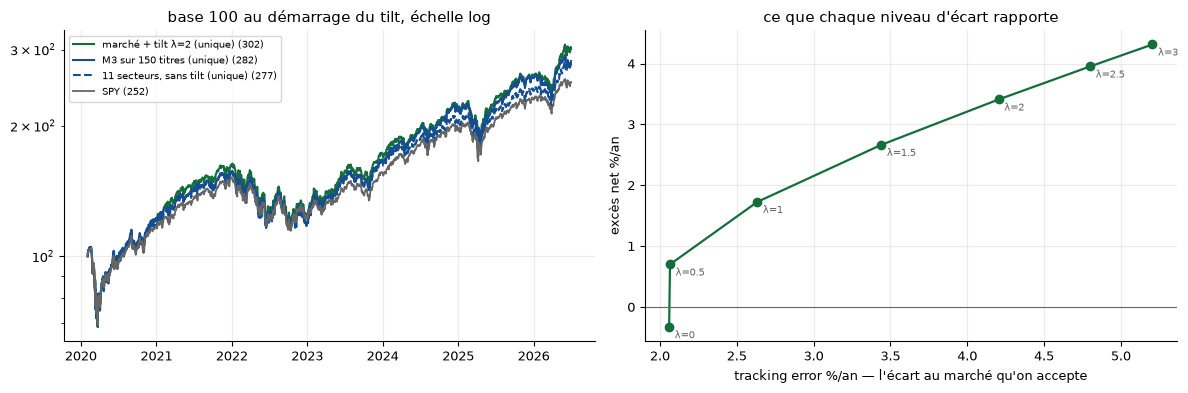

figure → /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/figs_nb15/etf_livrable.png


In [47]:
import os
FIGS15 = f"{RACINE}/00. S3S4 en cours/figs_nb15"
os.makedirs(FIGS15, exist_ok=True)

V_tilt = run_livre(livre_tilt_unique(2.0), np.inf, cuts=cuts_m)[0]
V_m3   = UNI["titres"];  V_m3 = V_m3[V_m3.index >= V_tilt.index[0]]
V_v2   = UNI["11 secteurs"]; V_v2 = V_v2[V_v2.index >= V_tilt.index[0]]
sp     = (1 + r_spy.reindex(V_tilt.index).fillna(0)).cumprod()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.0))
for V, c, ls, lab in [(V_tilt, VERT, "-",  "marché + tilt λ=2 (unique)"),
                      (V_m3,   BLEU, "-",  "M3 sur 150 titres (unique)"),
                      (V_v2,   BLEU, "--", "11 secteurs, sans tilt (unique)")]:
    s = V / V.iloc[0] * 100
    ax[0].plot(s.index, s, color=c, ls=ls, lw=1.5, label=f"{lab} ({s.iloc[-1]:.0f})")
s = sp / sp.iloc[0] * 100
ax[0].plot(s.index, s, color=GRIS, lw=1.3, label=f"SPY ({s.iloc[-1]:.0f})")
ax[0].set_yscale("log"); ax[0].legend(fontsize=7.5)
ax[0].set_title("base 100 au démarrage du tilt, échelle log")

T = pd.DataFrame(TU).set_index("λ")
ax[1].plot(T["tracking error %/an"], T["excès NET %/an"], "o-", color=VERT, lw=1.6)
for lam in T.index:
    ax[1].annotate(f"λ={lam:g}", (T.loc[lam, "tracking error %/an"], T.loc[lam, "excès NET %/an"]),
                   fontsize=7, xytext=(4, -8), textcoords="offset points", color=GRIS)
ax[1].axhline(0, color=GRIS, lw=0.8)
ax[1].set_xlabel("tracking error %/an — l'écart au marché qu'on accepte")
ax[1].set_ylabel("excès net %/an")
ax[1].set_title("ce que chaque niveau d'écart rapporte")
plt.tight_layout(); plt.savefig(f"{FIGS15}/etf_livrable.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"figure → {FIGS15}/etf_livrable.png")

### §9 — La carte historique : rendre à chaque titre le secteur qu'il avait

Jusqu'ici la carte titre $\to$ ETF est **celle d'aujourd'hui**, sans date. Un achat de Netflix en 2016 pointe
donc vers XLC, qui ne cote pas encore : la ligne est écartée et son poids renormalisé sur les autres secteurs.
C'est **équivalent à ne jamais avoir acheté ce titre** — 11 titres du top-150 en médiane (jusqu'à 20) sur les
52 coupes d'avant juin 2018.

Or ces titres **avaient un secteur**, et un ETF le portait. On le rend.

**Les deux bascules — dates d'INDICE, pas de cotation** (sources primaires SEC) :

| | l'ETF cote | le secteur GICS naît | **l'ETF source perd les titres** |
|---|---|---|---|
| XLRE | 08/10/2015 | 31/08/2016 | **16/09/2016** (formulaire 497 du 02/09/2016) |
| XLC | 19/06/2018 | 28/09/2018 | **21/09/2018** (SAI du 485BPOS du 15/06/2018) |

**Les deux règles, écrites avant tout backtest :**

1. **immobilier** — avant le 16/09/2016 le secteur Real Estate n'existe pas, l'immobilier est dans
   Financials : `XLRE` $\to$ **`XLF`**. Règle totale, aucune exception, aucun jugement (les *mortgage* REITs y
   restaient de toute façon).
2. **communication** — avant le 21/09/2018 le secteur n'existe pas ; ses titres venaient de trois endroits.
   Le discriminant est l'**industrie** (déjà en cache, §3) :
   - *Telecom Services*, *Internet Content & Information*, *Electronic Gaming & Multimedia* $\to$ **`XLK`**
     — il n'a jamais existé de SPDR télécom, l'indice Technology Select les englobait ;
   - *Entertainment*, *Advertising Agencies*, *Broadcasting*, *Publishing* $\to$ **`XLY`**.

   Les titres sans industrie sont des **sociétés disparues** — `yfinance` rend `None` pour ATVI, TWX, YHOO,
   LNKD, DTV, LVLT, TWTR, VIAC (vérifié). Ils reçoivent une **attribution nominative**, écrite ci-dessous et
   vérifiable une par une. Ce qui reste non attribué **garde le comportement actuel** : on ne devine jamais.

⚠️ **Huit tickers sont exclus des DEUX règles** : ce sont des **fonds**, pas des actions, et cinq d'entre eux
portent `asset_type = "Mutual Fund"` alors que `asset_class = "stock"` — la table se contredit. Deux entrent
réellement dans le top-150 : **PNQI** sur 10 coupes (démocrates, 10/2014 $\to$ 07/2015) et **SCHH** sur 4
(républicains, dès 02/2014). Les réattribuer aurait fait acheter un secteur au prétexte d'un fonds mal
étiqueté. **Retirer ces lignes du flux serait la vraie correction, mais elle déplacerait toutes les ancres du
projet** — c'est un chantier sur le pipeline S1/S2, consigné, pas traité ici.

⚠️ **Prédiction déclarée AVANT de lancer.** Le poids qui partait au prorata (y compris vers l'énergie et les
services publics) ira vers XLK et XLY. La technologie ayant monté sur la période, **l'excès 2014-2026 va
probablement augmenter**. Ce n'est pas un succès : c'est une correction de fidélité. On l'annonce ici pour
s'interdire de présenter après coup un chiffre plus flatteur comme une découverte.

**Statut, déclaré avant les chiffres** : la version historique est **primaire** parce qu'elle est plus fidèle.
L'actuelle reste publiée en regard. La fenêtre 2019-2026 n'est **pas** concernée — aucune de ses coupes n'a de
secteur manquant, donc le livrable ($\lambda = 2$) est intact quoi qu'il arrive.


In [48]:
# ══ §9.1 — les deux bascules, et la carte qui dépend de la date ══════════════════════════
BASC_RE = pd.Timestamp("2016-09-16")   # XLF cesse de porter l'immobilier
BASC_CS = pd.Timestamp("2018-09-21")   # XLK et XLY cessent de porter la communication

IND_VERS_BRANCHE = {                                   # l'industrie dit d'où le titre VENAIT
    "Telecom Services": "XLK", "Internet Content & Information": "XLK",
    "Electronic Gaming & Multimedia": "XLK",
    "Entertainment": "XLY", "Advertising Agencies": "XLY",
    "Broadcasting": "XLY", "Publishing": "XLY",
}

# les sociétés disparues : yfinance ne rend rien pour elles. Attribution nominative, opposable.
MANUEL_CS = {
    # ex-Telecommunication Services → XLK
    "LVLT":"XLK","CHL":"XLK","FTR":"XLK","CNSL":"XLK","BT":"XLK","NTT":"XLK","ZAYO":"XLK",
    "ORAN":"XLK","WIN":"XLK","TLSYY":"XLK","JCS":"XLK","DCM":"XLK","IQNT":"XLK","VODPD":"XLK",
    # ex-Information Technology (internet, jeux vidéo) → XLK
    "YNDX":"XLK","TWTR":"XLK","LNKD":"XLK","ATVI":"XLK","YHOO":"XLK","IACI":"XLK","JCOM":"XLK",
    "ZNGA":"XLK","RNWK":"XLK","ISDR":"XLK",
    # ex-Consumer Discretionary (médias, publicité) → XLY
    "VIAC":"XLY","SNI":"XLY","DISH":"XLY","TWX":"XLY","CMCSK":"XLY","MSG":"XLY","TGNA":"XLY",
    "GCI":"XLY","VIAB":"XLY","LTRPA":"XLY","LMCK":"XLY","LMCA":"XLY","MDCA":"XLY","WPPGY":"XLY",
    "IPG":"XLY","LSXMA":"XLY","LSXMK":"XLY","TIME":"XLY","DTV":"XLY","LGF-A":"XLY","SJR":"XLY",
}
# EXCLUS DES DEUX RÈGLES — ce sont des fonds, pas des actions. Ils gardent le comportement actuel.
#   EDR                            : description « EDUCATION RLTY TR », un REIT ; son etf_proxy XLC est faux
#   FDN, IXP, PNQI, VOX            : ETF classés XLC
#   VNQ, IYR, SCHH                 : ETF classés XLRE — sans cette exclusion, la règle immobilier les
#                                    enverrait vers XLF, et SCHH est dans le top-150 sur 4 coupes
# ⚠️ cinq d'entre eux portent asset_type == "Mutual Fund" ET asset_class == "stock" : la table se contredit.
HORS_CARTE = ["EDR", "FDN", "IXP", "PNQI", "VOX", "VNQ", "IYR", "SCHH"]

_CS = [t for t in CARTE.index[CARTE == "XLC"] if t not in HORS_CARTE]
_BR = pd.Series({t: (IND_VERS_BRANCHE.get(IND.get(t)) or MANUEL_CS.get(t)) for t in _CS}).dropna()
_RE = [t for t in CARTE.index[CARTE == "XLRE"] if t not in HORS_CARTE]

def carte_hist(i1):
    """La carte applicable à la coupe i1 : celle d'aujourd'hui, dé-corrigée des bascules postérieures."""
    d = cal[i1]
    if d >= BASC_CS: return CARTE                       # rien à corriger
    c = CARTE.copy()
    if d < BASC_RE: c.loc[_RE] = "XLF"                  # l'immobilier était dans Financials
    c.loc[_BR.index] = _BR.values                       # la communication, branche par branche
    return c

n_xlc = int((CARTE == "XLC").sum()); n_re = int((CARTE == "XLRE").sum())
print(f"communication : {len(_BR)}/{n_xlc} titres attribués "
      f"({(_BR == 'XLK').sum()} → XLK, {(_BR == 'XLY').sum()} → XLY) · "
      f"{n_xlc - len(_BR)} laissés au comportement actuel")
print(f"immobilier    : {len(_RE)}/{n_re} titres → XLF avant le {BASC_RE.date()}")
print(f"exclus des deux règles : {len(HORS_CARTE)} fonds — {', '.join(HORS_CARTE)}")

# (0) aucun des fonds exclus n'est réattribué, à AUCUNE coupe — le code doit dire ce que le texte annonce
for i1 in coupes[::11][:-1]:
    ch = carte_hist(i1)
    for t in HORS_CARTE:
        if t in ch.index:
            assert ch[t] == CARTE[t], f"{t} réattribué à la coupe {cal[i1].date()} : {CARTE[t]} → {ch[t]}"
print(f"✅ (0) les {len(HORS_CARTE)} fonds exclus gardent leur instrument d'origine à toute coupe")

# ── VALIDATION ───────────────────────────────────────────────────────────────────────────
# (1) la correction ne touche QUE le passé
for i1 in [i for i in coupes[:-1] if cal[i] >= BASC_CS]:
    assert carte_hist(i1).equals(CARTE), f"coupe {cal[i1].date()} : la carte d'aujourd'hui a été modifiée"
print(f"✅ (1) sur les {sum(1 for i in coupes[:-1] if cal[i] >= BASC_CS)} coupes ≥ {BASC_CS.date()}, "
      f"carte_hist ≡ CARTE — seul le passé change")

# (2) combien de titres du top-150 restent sans instrument, avant et après ?
def sans_instrument(i1, parti, carte):
    w = poids_methode(i1, parti)
    if not w: return 0, 0.0
    s = pd.Series(w); cle = carte.reindex(s.index)
    mort = [t for t, e in cle.items()
            if not (isinstance(e, str) and e in PXV and np.isfinite(PXV[e][i1+1]) and vivant(e, i1))]
    return len(mort), float(s[mort].sum())

AV = []
for parti, nom in PARTIS:
    for i1 in [i for i in coupes[:-1] if cal[i] < BASC_CS]:
        a_n, a_w = sans_instrument(i1, parti, CARTE)
        h_n, h_w = sans_instrument(i1, parti, carte_hist(i1))
        AV.append({"fonds": nom, "avant · titres": a_n, "avant · poids %": 100*a_w,
                   "après · titres": h_n, "après · poids %": 100*h_w})
AV = pd.DataFrame(AV).groupby("fonds").agg(["median", "max"]).round(1)
display(AV)
print("✅ (2) les titres sans instrument avant/après la carte historique (médiane et max sur les 52 coupes)")


communication : 113/136 titres attribués (71 → XLK, 42 → XLY) · 23 laissés au comportement actuel
immobilier    : 167/170 titres → XLF avant le 2016-09-16
exclus des deux règles : 8 fonds — EDR, FDN, IXP, PNQI, VOX, VNQ, IYR, SCHH
✅ (0) les 8 fonds exclus gardent leur instrument d'origine à toute coupe
✅ (1) sur les 93 coupes ≥ 2018-09-21, carte_hist ≡ CARTE — seul le passé change


avant · titres     avant · poids %       après · titres     après · poids %     
              median max          median   max         median max          median  max
fonds                                                                                 
GOP              9.0  18            11.8  16.1            0.0   1             0.0  0.2
NANC            11.0  13            15.2  20.8            0.0   1             0.0  0.2

✅ (2) les titres sans instrument avant/après la carte historique (médiane et max sur les 52 coupes)


In [49]:
# ══ §9.2 — rejouer avec la carte historique, et publier les deux versions ════════════════
HIST = {}
for parti, nom in PARTIS:
    HIST[nom] = run_livre({i: poids_agrege(i, parti, carte=carte_hist(i)) for i in coupes[:-1]}, np.inf)[0]
HIST["UNIQUE"] = run_livre({i: agrege_tous(i, carte=carte_hist(i)) for i in coupes[:-1]}, np.inf)[0]

ACTU = {"NANC": REF[("V2 · 11 secteurs", "NANC")], "GOP": REF[("V2 · 11 secteurs", "GOP")],
        "UNIQUE": UNI["11 secteurs"]}

L = []
for nom in ["NANC", "GOP", "UNIQUE"]:
    for lab, V in [("historique (primaire)", HIST[nom]), ("carte d'aujourd'hui (regard)", ACTU[nom])]:
        b = bilan_ic(V, f"{nom} · {lab}"); b19 = bilan(V[V.index >= D19], "x")
        L.append({"signal": nom, "carte": lab, "excès 2014+ %/an": b["excès %/an"], "t": b["t"],
                  "α₁ 2014+ %/an": b["α %/an"], "excès 2019+ %/an": b19["excès %/an"],
                  "α₁ 2019+ %/an": b19["α %/an"], "β": b["β"], "NAV": b["NAV"]})
THIST = pd.DataFrame(L).set_index(["signal", "carte"])
display(THIST.round(2))

# ── VALIDATION ───────────────────────────────────────────────────────────────────────────
# (3) non-régression : la carte ne touche pas la version titres
assert abs(REF[("M3 · titres","NANC")].iloc[-1] - 661.57) < 0.01
assert abs(REF[("M3 · titres","GOP")].iloc[-1]  - 573.57) < 0.01
print("✅ (3) non-régression — M3-titres inchangée (661,57 / 573,57)")

# (4) Σw = 1 et univers dans les 11 SPDR, à chaque coupe
nc = 0
for parti, nom in PARTIS:
    for i1 in coupes[:-1]:
        w = poids_agrege(i1, parti, carte=carte_hist(i1))
        if not w: continue
        assert abs(sum(w.values()) - 1) < 1e-12, f"{nom} coupe {cal[i1].date()} : Σw ≠ 1"
        assert set(w) <= set(ETF_SECT), f"{nom} coupe {cal[i1].date()} : instrument hors des 11 SPDR"
        nc += 1
print(f"✅ (4) Σw = 1 et univers ⊆ 11 SPDR sur les {nc} coupes des deux partis")

# (5) après les bascules, les deux versions sont le MÊME portefeuille
ec = 0.0
for parti, nom in PARTIS:
    for i1 in [i for i in coupes[:-1] if cal[i] >= BASC_CS]:
        a, h = poids_agrege(i1, parti), poids_agrege(i1, parti, carte=carte_hist(i1))
        assert set(a) == set(h)
        ec = max(ec, max(abs(a[k]-h[k]) for k in a)) if a else ec
assert ec < 1e-15, f"écart {ec:.1e} après les bascules"
print(f"✅ (5) après {BASC_CS.date()} les deux cartes donnent le même portefeuille (écart max {ec:.1e})")


excès 2014+ %/an     t  α₁ 2014+ %/an  excès 2019+ %/an  α₁ 2019+ %/an     β     NAV
signal carte                                                                                                             
NANC   historique (primaire)                     1.78  1.66           0.59              1.92           0.20  1.05  586.03
       carte d'aujourd'hui (regard)              1.50  1.38           0.30              1.92           0.20  1.05  565.34
GOP    historique (primaire)                     0.78  1.02           0.41              1.12           0.65  1.02  551.95
       carte d'aujourd'hui (regard)              0.45  0.57           0.09              1.12           0.65  1.01  530.37
UNIQUE historique (primaire)                     1.45  2.05           0.46              1.70           0.32  1.04  576.90
       carte d'aujourd'hui (regard)              1.15  1.54           0.16              1.70           0.32  1.04  555.42

✅ (3) non-régression — M3-titres inchangée (661,57 / 573,57)


✅ (4) Σw = 1 et univers ⊆ 11 SPDR sur les 296 coupes des deux partis


✅ (5) après 2018-09-21 les deux cartes donnent le même portefeuille (écart max 0.0e+00)


### Les questions à poser à Ramify avant d'aller plus loin

Aucune contrainte n'a été supposée dans ce notebook. Quatre réponses changeraient la version à retenir :

1. **Combien de lignes** le portefeuille peut-il porter ? *(11, 30, ou davantage — cela départage
   directement les versions)*
2. **Quel univers est autorisé** : les ETF américains cités ici, ou faut-il des équivalents **UCITS** ?
   Plusieurs des ETF fins n'ont pas d'équivalent européen.
3. **Quel écart à l'indice** est acceptable ? Le §5 montre que le tracking error se pilote continûment
   de 2 à 6 %/an — encore faut-il savoir où se situe la limite.
4. **Quelle rotation** est tolérée, et à quel coût réel ? Les 10 points de base retenus ici sont une
   convention, pas leur barème.